In [1]:
# ============================================
# CELL 1: IMPORT LIBRARIES (FOREIGN LANGUAGES)
# Spanish / German / Italian - Unified Box
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix

import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=" * 60)
print("📚 LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)
print(f"✅ Pandas version: {pd.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print(f"✅ Scikit-learn version: {sklearn.__version__}")
print(f"✅ SHAP version: {shap.__version__}")
print("=" * 60)
print("\n🚀 Ready to generate Foreign Languages dataset")
print("   (Spanish / German / Italian - Unified Box)")
print("=" * 60)

📚 LIBRARIES IMPORTED SUCCESSFULLY
✅ Pandas version: 2.3.3
✅ NumPy version: 2.3.5
✅ Scikit-learn version: 1.8.0
✅ SHAP version: 0.51.0

🚀 Ready to generate Foreign Languages dataset
   (Spanish / German / Italian - Unified Box)


In [2]:
# ============================================
# CELL 2: GENERATE DATASET (FOREIGN LANGUAGES)
# Spanish / German / Italian - Unified Box
# 500 students, mean ~13/20, normal distribution
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("📚 GENERATING FOREIGN LANGUAGES DATASET")
print(f"Number of students: {n_students}")
print("Languages: Spanish (0), German (1), Italian (2)")
print("Target mean: ~13/20")
print("=" * 60)

# ============================================
# STEP 1: Generate Base Ability
# ============================================

# Base skill level for foreign language learning
base_skill = np.random.normal(6.5, 1.5, n_students)
base_skill = np.clip(base_skill, 3, 9.5)

# ============================================
# A. Reading & Comprehension Skills (5 features)
# ============================================

main_idea_detection = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
detail_extraction = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
true_false_accuracy = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
reference_resolution = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
inference_skill = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)

# ============================================
# B. Linguistic Competence Skills (7 features)
# ============================================

synonym_antonym = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
word_formation = np.clip(base_skill - 0.3 + np.random.normal(0, 0.9, n_students), 2, 10)
tense_mastery = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
grammar_transformation = np.clip(base_skill - 0.5 + np.random.normal(0, 0.9, n_students), 2, 10)
sentence_rewriting = np.clip(base_skill - 0.3 + np.random.normal(0, 0.9, n_students), 2, 10)
preposition_mastery = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
translation_skill = np.clip(base_skill - 0.4 + np.random.normal(0, 0.9, n_students), 2, 10)

# ============================================
# C. Writing Skills (4 features)
# ============================================

paragraph_structure = np.clip(base_skill - 0.5 + np.random.normal(0, 0.9, n_students), 2, 10)
coherence_cohesion = np.clip(base_skill - 0.3 + np.random.normal(0, 0.9, n_students), 2, 10)
idea_development = np.clip(base_skill - 0.3 + np.random.normal(0, 0.9, n_students), 2, 10)
language_accuracy = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)

# ============================================
# D. Practice & Study Habits
# ============================================

texts_read_per_week = np.random.choice([0,1,2,3,4,5,6,7,8,9,10], n_students, 
                                        p=[0.05,0.05,0.1,0.1,0.15,0.15,0.15,0.1,0.05,0.05,0.05])
exercises_done_per_week = np.random.poisson(5, n_students)
exercises_done_per_week = np.clip(exercises_done_per_week, 0, 20)
bac_subjects_practiced = np.random.poisson(4, n_students)
bac_subjects_practiced = np.clip(bac_subjects_practiced, 0, 20)
writing_tasks_per_week = np.random.choice([0,1,2,3,4,5], n_students, p=[0.05,0.1,0.3,0.3,0.15,0.1])

# ============================================
# E. Psychological Factors
# ============================================

confidence = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.3,0.35,0.2])
stress = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.25,0.35,0.25])

# ============================================
# F. Language Type (0=Spanish, 1=German, 2=Italian)
# ============================================

language = np.random.choice([0, 1, 2], n_students, p=[0.4, 0.3, 0.3])

# Language difficulty adjustment (German is harder)
lang_difficulty = np.where(language == 1, -0.3, np.where(language == 2, 0.1, 0))

# ============================================
# G. Academic History (Trimester Grades)
# ============================================

# Generate avg_grade from skills
avg_grade = (
    0.15 * main_idea_detection +
    0.10 * detail_extraction +
    0.10 * grammar_transformation +
    0.10 * tense_mastery +
    0.10 * paragraph_structure +
    0.10 * (bac_subjects_practiced / 2) +
    0.05 * texts_read_per_week +
    0.05 * exercises_done_per_week
) * 2

avg_grade = np.clip(avg_grade, 8, 19.5)
avg_grade = np.round(avg_grade, 1)

# Generate trimester grades
grade_t1 = avg_grade + np.random.normal(-0.5, 1.0, n_students)
grade_t2 = avg_grade + np.random.normal(0, 0.9, n_students)
grade_t3 = avg_grade + np.random.normal(0.5, 0.8, n_students)

grade_t1 = np.clip(grade_t1, 8, 19.5)
grade_t2 = np.clip(grade_t2, 8, 19.5)
grade_t3 = np.clip(grade_t3, 8, 19.5)

grade_t1 = np.round(grade_t1, 1)
grade_t2 = np.round(grade_t2, 1)
grade_t3 = np.round(grade_t3, 1)

grade_trend = grade_t3 - grade_t1
grade_trend = np.round(grade_trend, 1)

# ============================================
# H. Calculate BAC Score
# ============================================

# Scale practice features
bac_subjects_scaled = (bac_subjects_practiced / 20) * 10
exercises_scaled = (exercises_done_per_week / 20) * 10
reading_scaled = (texts_read_per_week / 10) * 10
writing_scaled = (writing_tasks_per_week / 5) * 10

bac_score = (
    # Reading & Comprehension (35%)
    0.10 * main_idea_detection +
    0.08 * detail_extraction +
    0.07 * true_false_accuracy +
    0.05 * reference_resolution +
    0.05 * inference_skill +
    
    # Linguistic Competence (40%)
    0.07 * synonym_antonym +
    0.06 * word_formation +
    0.07 * tense_mastery +
    0.07 * grammar_transformation +
    0.05 * sentence_rewriting +
    0.04 * preposition_mastery +
    0.04 * translation_skill +
    
    # Writing Skills (25%)
    0.08 * paragraph_structure +
    0.06 * coherence_cohesion +
    0.06 * idea_development +
    0.05 * language_accuracy +
    
    # Practice bonus
    0.03 * bac_subjects_scaled +
    0.02 * exercises_scaled +
    0.02 * reading_scaled +
    0.02 * writing_scaled
) * 1.8

# Add psychological adjustments
bac_score = bac_score + (confidence - 3) * 0.1 - (stress - 3) * 0.05

# Add language difficulty adjustment
bac_score = bac_score + lang_difficulty

# Add noise
bac_score = bac_score + np.random.normal(0, 0.4, n_students)

# Adjust to target mean ~13
current_mean = bac_score.mean()
target_mean = 13.0
bac_score = bac_score * (target_mean / current_mean)

# Clip to realistic range
bac_score = np.clip(bac_score, 8, 19.5)
bac_score = np.round(bac_score, 1)

# ============================================
# Round all skills
# ============================================

main_idea_detection = np.round(main_idea_detection, 1)
detail_extraction = np.round(detail_extraction, 1)
true_false_accuracy = np.round(true_false_accuracy, 1)
reference_resolution = np.round(reference_resolution, 1)
inference_skill = np.round(inference_skill, 1)

synonym_antonym = np.round(synonym_antonym, 1)
word_formation = np.round(word_formation, 1)
tense_mastery = np.round(tense_mastery, 1)
grammar_transformation = np.round(grammar_transformation, 1)
sentence_rewriting = np.round(sentence_rewriting, 1)
preposition_mastery = np.round(preposition_mastery, 1)
translation_skill = np.round(translation_skill, 1)

paragraph_structure = np.round(paragraph_structure, 1)
coherence_cohesion = np.round(coherence_cohesion, 1)
idea_development = np.round(idea_development, 1)
language_accuracy = np.round(language_accuracy, 1)

# ============================================
# Create DataFrame
# ============================================

df = pd.DataFrame({
    # Academic History
    'grade_t1': grade_t1,
    'grade_t2': grade_t2,
    'grade_t3': grade_t3,
    'avg_grade': avg_grade,
    'grade_trend': grade_trend,
    
    # Reading & Comprehension
    'main_idea_detection': main_idea_detection,
    'detail_extraction': detail_extraction,
    'true_false_accuracy': true_false_accuracy,
    'reference_resolution': reference_resolution,
    'inference_skill': inference_skill,
    
    # Linguistic Competence
    'synonym_antonym': synonym_antonym,
    'word_formation': word_formation,
    'tense_mastery': tense_mastery,
    'grammar_transformation': grammar_transformation,
    'sentence_rewriting': sentence_rewriting,
    'preposition_mastery': preposition_mastery,
    'translation_skill': translation_skill,
    
    # Writing Skills
    'paragraph_structure': paragraph_structure,
    'coherence_cohesion': coherence_cohesion,
    'idea_development': idea_development,
    'language_accuracy': language_accuracy,
    
    # Practice & Study Habits
    'texts_read_per_week': texts_read_per_week,
    'exercises_done_per_week': exercises_done_per_week,
    'bac_subjects_practiced': bac_subjects_practiced,
    'writing_tasks_per_week': writing_tasks_per_week,
    
    # Psychological
    'confidence': confidence,
    'stress': stress,
    
    # Context
    'language': language,
    
    # Target
    'bac_score': bac_score
})

print("\n✅ Dataset generated successfully!")
print(f"   Students: {df.shape[0]}")
print(f"   Features: {df.shape[1]}")
print(f"\n📊 BAC Score Statistics:")
print(f"   Mean: {df['bac_score'].mean():.2f}/20")
print(f"   Min: {df['bac_score'].min():.1f}/20")
print(f"   Max: {df['bac_score'].max():.1f}/20")
print(f"   Std: {df['bac_score'].std():.2f}")

print("\n📊 BAC Score Distribution:")
print(f"   8-10:   {((df['bac_score'] >= 8) & (df['bac_score'] < 11)).sum()} students")
print(f"   11-12:  {((df['bac_score'] >= 11) & (df['bac_score'] < 13)).sum()} students")
print(f"   13-14:  {((df['bac_score'] >= 13) & (df['bac_score'] < 15)).sum()} students")
print(f"   15-16:  {((df['bac_score'] >= 15) & (df['bac_score'] < 17)).sum()} students")
print(f"   17-19:  {(df['bac_score'] >= 17).sum()} students")

print("\n📊 Correlations with BAC Score:")
print(f"   main_idea_detection: {df['bac_score'].corr(df['main_idea_detection']):.3f}")
print(f"   grammar_transformation: {df['bac_score'].corr(df['grammar_transformation']):.3f}")
print(f"   tense_mastery: {df['bac_score'].corr(df['tense_mastery']):.3f}")
print(f"   paragraph_structure: {df['bac_score'].corr(df['paragraph_structure']):.3f}")
print(f"   avg_grade: {df['bac_score'].corr(df['avg_grade']):.3f}")
print(f"   bac_subjects_practiced: {df['bac_score'].corr(df['bac_subjects_practiced']):.3f}")

print("\n📊 By Language:")
for lang_code in [0, 1, 2]:
    lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[lang_code]
    subset = df[df['language'] == lang_code]
    print(f"   {lang_name}: {len(subset)} students, Mean BAC: {subset['bac_score'].mean():.2f}/20")

print("\n📊 First 5 rows:")
print(df.head())

📚 GENERATING FOREIGN LANGUAGES DATASET
Number of students: 500
Languages: Spanish (0), German (1), Italian (2)
Target mean: ~13/20

✅ Dataset generated successfully!
   Students: 500
   Features: 29

📊 BAC Score Statistics:
   Mean: 13.03/20
   Min: 8.0/20
   Max: 19.5/20
   Std: 2.72

📊 BAC Score Distribution:
   8-10:   112 students
   11-12:  137 students
   13-14:  125 students
   15-16:  81 students
   17-19:  45 students

📊 Correlations with BAC Score:
   main_idea_detection: 0.872
   grammar_transformation: 0.853
   tense_mastery: 0.858
   paragraph_structure: 0.828
   avg_grade: 0.865
   bac_subjects_practiced: 0.058

📊 By Language:
   Spanish: 192 students, Mean BAC: 12.84/20
   German: 151 students, Mean BAC: 12.76/20
   Italian: 157 students, Mean BAC: 13.53/20

📊 First 5 rows:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  main_idea_detection  detail_extraction  true_false_accuracy  reference_resolution  inference_skill  synonym_antonym  word_formation  tense_mast

In [3]:
# ============================================
# CELL 3: SAVE DATASET (FOREIGN LANGUAGES)
# ============================================

# Save the dataset to CSV file
csv_filename = 'foreign_languages_bac_dataset.csv'

df.to_csv(csv_filename, index=False)

print("=" * 60)
print("💾 DATASET SAVED SUCCESSFULLY")
print("=" * 60)
print(f"   File: {csv_filename}")
print(f"   Students: {df.shape[0]}")
print(f"   Features: {df.shape[1]}")
print("=" * 60)

# Display file size
import os
file_size = os.path.getsize(csv_filename)
print(f"   File size: {file_size / 1024:.2f} KB")
print("=" * 60)

print("\n📊 Preview of saved data (first 3 rows):")
print(df.head(3))

print("\n📊 Column names:")
print(df.columns.tolist())

print("\n📊 Language distribution in saved dataset:")
for lang_code in [0, 1, 2]:
    lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[lang_code]
    count = (df['language'] == lang_code).sum()
    print(f"   {lang_name}: {count} students ({count/len(df)*100:.1f}%)")

NameError: name 'df' is not defined

In [2]:
# ============================================
# CELL 4: LOAD DATASET (FOREIGN LANGUAGES)
# ============================================

# Load the dataset from CSV file
csv_filename = 'foreign_languages_bac_dataset.csv'

df = pd.read_csv(csv_filename)

print("=" * 60)
print("📂 DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"   File: {csv_filename}")
print(f"   Students: {df.shape[0]}")
print(f"   Features: {df.shape[1]}")
print("=" * 60)

print("\n📊 Quick statistics:")
print(f"   BAC Score - Mean: {df['bac_score'].mean():.2f}/20")
print(f"   BAC Score - Min: {df['bac_score'].min():.1f}/20")
print(f"   BAC Score - Max: {df['bac_score'].max():.1f}/20")
print(f"   BAC Score - Std: {df['bac_score'].std():.2f}")

print("\n📊 First 3 rows:")
print(df.head(3))

print("\n📊 Column names:")
print(df.columns.tolist())

print("\n📊 Language distribution:")
for lang_code in [0, 1, 2]:
    lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[lang_code]
    count = (df['language'] == lang_code).sum()
    print(f"   {lang_name}: {count} students ({count/len(df)*100:.1f}%)")

📂 DATASET LOADED SUCCESSFULLY
   File: foreign_languages_bac_dataset.csv
   Students: 500
   Features: 29

📊 Quick statistics:
   BAC Score - Mean: 13.03/20
   BAC Score - Min: 8.0/20
   BAC Score - Max: 19.5/20
   BAC Score - Std: 2.72

📊 First 3 rows:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  main_idea_detection  detail_extraction  true_false_accuracy  reference_resolution  inference_skill  synonym_antonym  word_formation  tense_mastery  grammar_transformation  sentence_rewriting  preposition_mastery  translation_skill  paragraph_structure  coherence_cohesion  idea_development  language_accuracy  texts_read_per_week  exercises_done_per_week  bac_subjects_practiced  writing_tasks_per_week  confidence  stress  language  bac_score
0       9.5       8.5       9.4        9.0         -0.1                  8.0                8.4                  7.9                   6.7              7.7              5.7             8.0            6.6                     5.9                 6

In [6]:
# ============================================
# CELL 5: EDA - OVERVIEW (FOREIGN LANGUAGES)
# ============================================

print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS - OVERVIEW")
print("=" * 60)

# 1. First 5 rows
print("\n📋 FIRST 5 ROWS:")
print(df.head())

# 2. Last 5 rows
print("\n📋 LAST 5 ROWS:")
print(df.tail())

# 3. Dataset info
print("\n📋 DATASET INFO:")
print(df.info())

# 4. Summary statistics
print("\n📋 SUMMARY STATISTICS:")
print(df.describe().round(2))

# 5. Missing values check
print("\n📋 MISSING VALUES:")
missing = df.isnull().sum().sum()
if missing == 0:
    print("   ✅ No missing values")
else:
    print(f"   ⚠️ {missing} missing values found")

# 6. Duplicate rows check
print("\n📋 DUPLICATE ROWS:")
duplicates = df.duplicated().sum()
if duplicates == 0:
    print("   ✅ No duplicate rows")
else:
    print(f"   ⚠️ {duplicates} duplicate rows found")

# 7. Data types summary
print("\n📋 DATA TYPES SUMMARY:")
print(df.dtypes.value_counts())

# 8. Dataset shape
print("\n📋 DATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# 9. Memory usage
print("\n📋 MEMORY USAGE:")
print(f"   {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# 10. Column names list
print("\n📋 ALL COLUMN NAMES:")
print(df.columns.tolist())

# 11. Language distribution
print("\n📋 LANGUAGE DISTRIBUTION:")
for lang_code in [0, 1, 2]:
    lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[lang_code]
    count = (df['language'] == lang_code).sum()
    pct = count / len(df) * 100
    print(f"   {lang_name}: {count} students ({pct:.1f}%)")

# 12. BAC score by language
print("\n📋 BAC SCORE BY LANGUAGE:")
for lang_code in [0, 1, 2]:
    lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[lang_code]
    subset = df[df['language'] == lang_code]
    print(f"   {lang_name}: Mean = {subset['bac_score'].mean():.2f}/20, Std = {subset['bac_score'].std():.2f}")

print("\n" + "=" * 60)
print("✅ EDA OVERVIEW COMPLETE")
print("=" * 60)

📊 EXPLORATORY DATA ANALYSIS - OVERVIEW

📋 FIRST 5 ROWS:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  main_idea_detection  detail_extraction  true_false_accuracy  reference_resolution  inference_skill  synonym_antonym  word_formation  tense_mastery  grammar_transformation  sentence_rewriting  preposition_mastery  translation_skill  paragraph_structure  coherence_cohesion  idea_development  language_accuracy  texts_read_per_week  exercises_done_per_week  bac_subjects_practiced  writing_tasks_per_week  confidence  stress  language  bac_score
0       9.5       8.5       9.4        9.0         -0.1                  8.0                8.4                  7.9                   6.7              7.7              5.7             8.0            6.6                     5.9                 6.6                  7.8                5.8                  7.8                 7.7               8.5                7.2                    5                        3                       1        

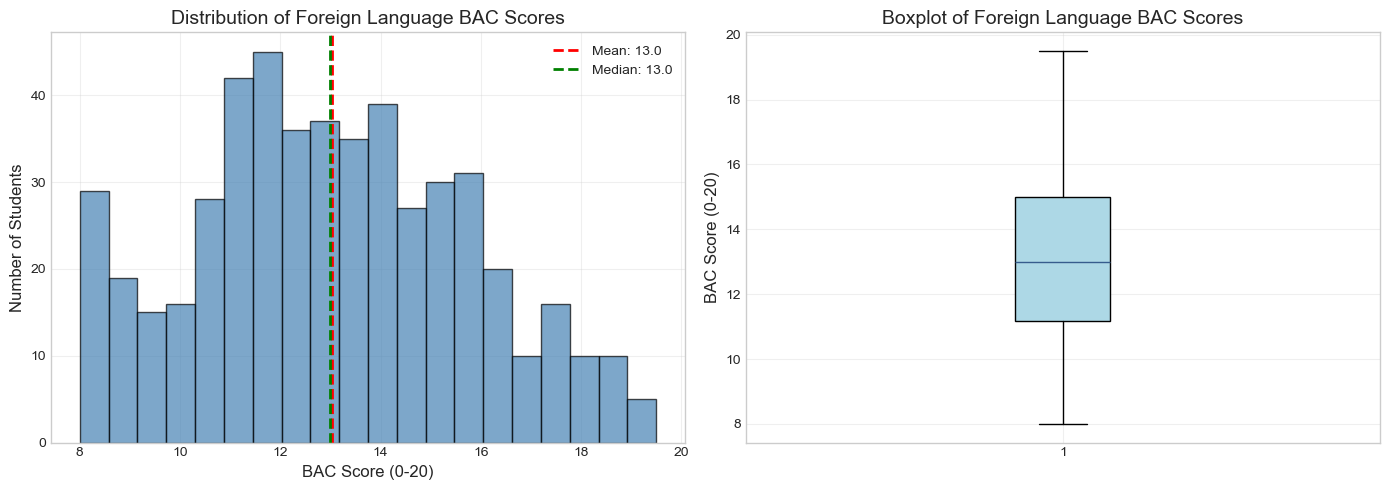


📊 BAC SCORE STATISTICS
   Mean:     13.03
   Median:   13.00
   Mode:     8.00
   Std Dev:  2.72
   Min:      8.0
   Max:      19.5
   Range:    11.5

📊 PERCENTILES:
   10th percentile: 9.20
   25th percentile: 11.17
   50th percentile: 13.00
   75th percentile: 15.00
   90th percentile: 16.70

📊 SCORE DISTRIBUTION BY RANGE:
    8 - 10:  71 students ( 14.2%) ███████
   10 - 12: 114 students ( 22.8%) ███████████
   12 - 14: 128 students ( 25.6%) ████████████
   14 - 16: 113 students ( 22.6%) ███████████
   16 - 18:  53 students ( 10.6%) █████
   18 - 20:  21 students (  4.2%) ██

📊 PASSING RATE (score ≥ 10): 85.8%
📊 EXCELLENCE RATE (score ≥ 16): 14.8%

📊 BAC SCORE BY LANGUAGE:
   Spanish: Mean = 12.84/20, Pass rate = 84.4%
   German: Mean = 12.76/20, Pass rate = 82.8%
   Italian: Mean = 13.53/20, Pass rate = 90.4%

✅ BAC SCORE DISTRIBUTION COMPLETE


In [7]:
# ============================================
# CELL 6: EDA - BAC SCORE DISTRIBUTION (FOREIGN LANGUAGES)
# ============================================

import matplotlib.pyplot as plt

# Create figure with 2 graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Histogram
axes[0].hist(df['bac_score'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(df['bac_score'].mean(), color='red', linestyle='dashed', linewidth=2, 
                label=f'Mean: {df["bac_score"].mean():.1f}')
axes[0].axvline(df['bac_score'].median(), color='green', linestyle='dashed', linewidth=2, 
                label=f'Median: {df["bac_score"].median():.1f}')
axes[0].set_xlabel('BAC Score (0-20)', fontsize=12)
axes[0].set_ylabel('Number of Students', fontsize=12)
axes[0].set_title('Distribution of Foreign Language BAC Scores', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graph 2: Boxplot
boxplot = axes[1].boxplot(df['bac_score'], vert=True, patch_artist=True)
boxplot['boxes'][0].set_facecolor('lightblue')
axes[1].set_ylabel('BAC Score (0-20)', fontsize=12)
axes[1].set_title('Boxplot of Foreign Language BAC Scores', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed statistics
print("\n" + "=" * 60)
print("📊 BAC SCORE STATISTICS")
print("=" * 60)
print(f"   Mean:     {df['bac_score'].mean():.2f}")
print(f"   Median:   {df['bac_score'].median():.2f}")
print(f"   Mode:     {df['bac_score'].mode().values[0]:.2f}")
print(f"   Std Dev:  {df['bac_score'].std():.2f}")
print(f"   Min:      {df['bac_score'].min():.1f}")
print(f"   Max:      {df['bac_score'].max():.1f}")
print(f"   Range:    {df['bac_score'].max() - df['bac_score'].min():.1f}")

# Percentiles
print("\n📊 PERCENTILES:")
for p in [10, 25, 50, 75, 90]:
    print(f"   {p}th percentile: {df['bac_score'].quantile(p/100):.2f}")

# Distribution by range
print("\n📊 SCORE DISTRIBUTION BY RANGE:")
ranges = [(8, 10), (10, 12), (12, 14), (14, 16), (16, 18), (18, 20)]
for low, high in ranges:
    count = ((df['bac_score'] >= low) & (df['bac_score'] < high)).sum()
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"   {low:2d} - {high:2d}: {count:3d} students ({pct:5.1f}%) {bar}")

# Passing rate
passing_rate = (df['bac_score'] >= 10).mean() * 100
print(f"\n📊 PASSING RATE (score ≥ 10): {passing_rate:.1f}%")

# Excellence rate
excellence_rate = (df['bac_score'] >= 16).mean() * 100
print(f"📊 EXCELLENCE RATE (score ≥ 16): {excellence_rate:.1f}%")

# By language
print("\n📊 BAC SCORE BY LANGUAGE:")
for lang_code in [0, 1, 2]:
    lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[lang_code]
    subset = df[df['language'] == lang_code]
    print(f"   {lang_name}: Mean = {subset['bac_score'].mean():.2f}/20, Pass rate = {(subset['bac_score'] >= 10).mean() * 100:.1f}%")

print("\n" + "=" * 60)
print("✅ BAC SCORE DISTRIBUTION COMPLETE")
print("=" * 60)


📊 CORRELATION WITH BAC SCORE
(Highest to lowest)
---------------------------------------------
   bac_score                     : 1.000
   true_false_accuracy           : 0.875
   main_idea_detection           : 0.872
   avg_grade                     : 0.865
   reference_resolution          : 0.863
   detail_extraction             : 0.862
   inference_skill               : 0.861
   synonym_antonym               : 0.861
   tense_mastery                 : 0.858
   preposition_mastery           : 0.856
   grammar_transformation        : 0.853
   coherence_cohesion            : 0.847
   language_accuracy             : 0.842
   translation_skill             : 0.840
   sentence_rewriting            : 0.840
   paragraph_structure           : 0.828
   idea_development              : 0.828
   word_formation                : 0.827
   grade_t3                      : 0.698
   grade_t1                      : 0.661
   grade_t2                      : 0.632
   grade_trend                   : 0.180
  

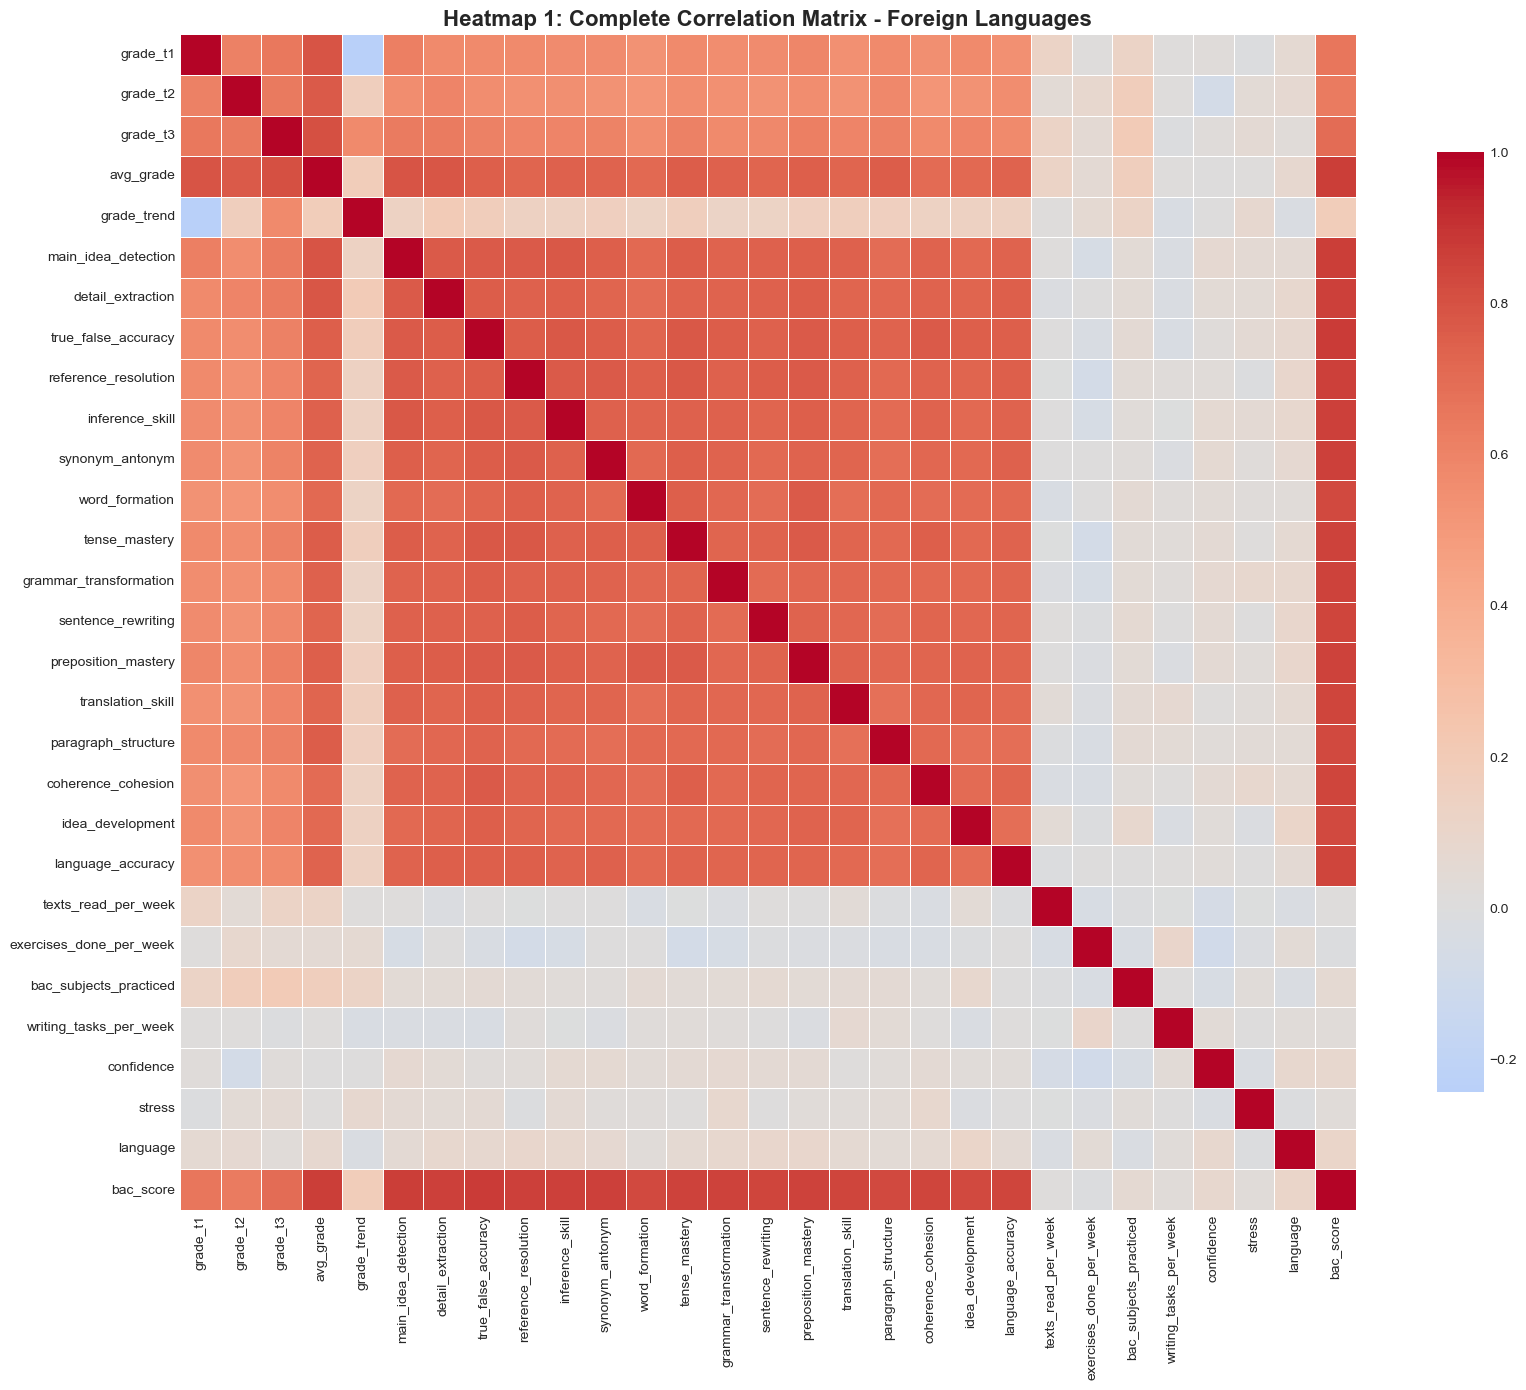


📊 HEATMAP 2: Top 15 Features Correlated with BAC Score


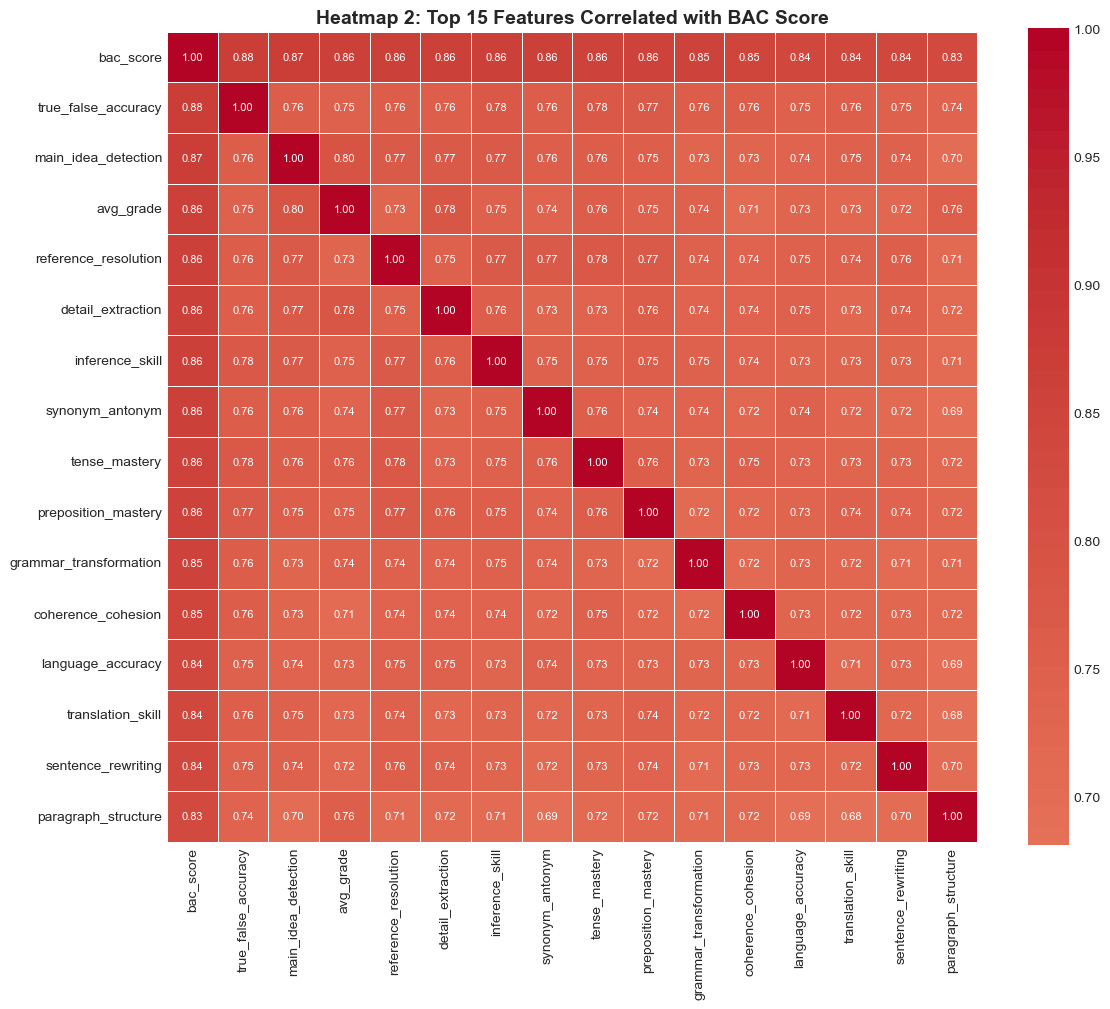


📊 HEATMAP 3: Core Skill Categories Correlation


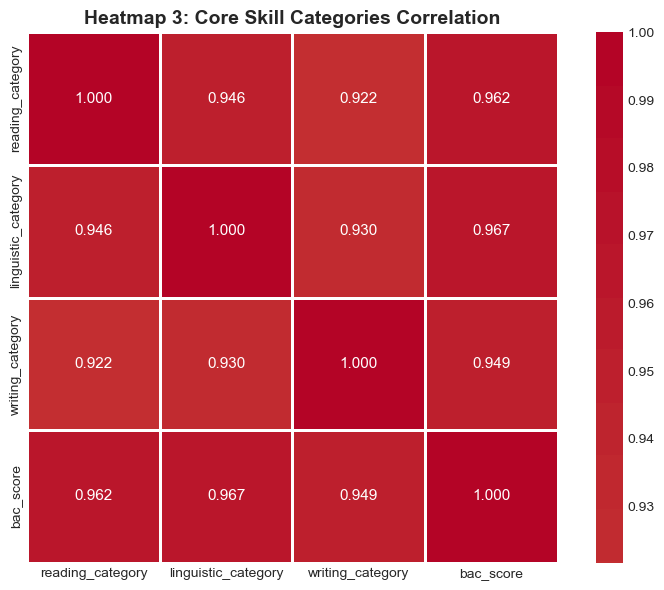


📊 HEATMAP 4: Remaining Features (Lower Correlation with BAC)


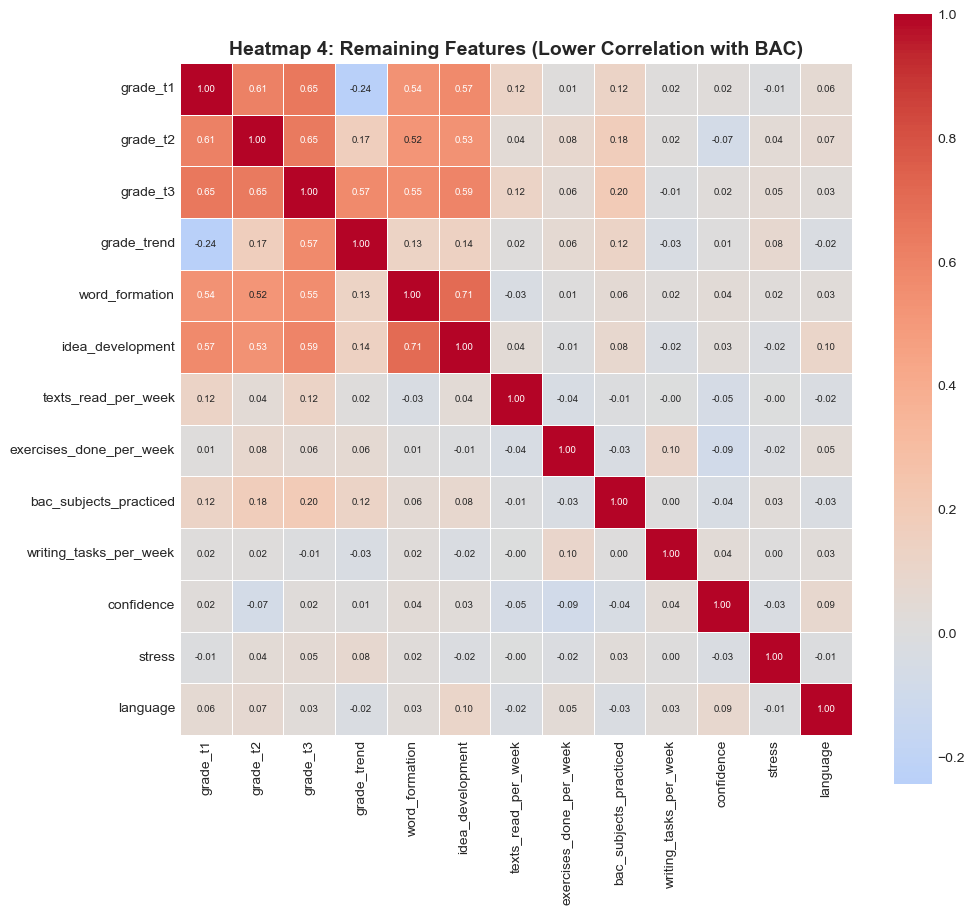


📋 Remaining features (13 features):
   • grade_t1: correlation = 0.661
   • grade_t2: correlation = 0.632
   • grade_t3: correlation = 0.698
   • grade_trend: correlation = 0.180
   • word_formation: correlation = 0.827
   • idea_development: correlation = 0.828
   • texts_read_per_week: correlation = 0.013
   • exercises_done_per_week: correlation = -0.008
   • bac_subjects_practiced: correlation = 0.058
   • writing_tasks_per_week: correlation = 0.033
   • confidence: correlation = 0.086
   • stress: correlation = 0.024
   • language: correlation = 0.102

✅ CORRELATION HEATMAPS COMPLETE


In [9]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS (FOREIGN LANGUAGES)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Correlation with BAC score
bac_corr = corr_matrix['bac_score'].sort_values(ascending=False)
print("\n" + "=" * 60)
print("📊 CORRELATION WITH BAC SCORE")
print("=" * 60)
print("(Highest to lowest)")
print("-" * 45)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:30s}: {corr_value:.3f}")

# ============================================
# HEATMAP 1: All Features
# ============================================
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap 1: Complete Correlation Matrix - Foreign Languages', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 2: Top 15 Features Correlated with BAC
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 2: Top 15 Features Correlated with BAC Score")
print("=" * 60)

# Get top 15 features (including bac_score itself)
top_features = bac_corr.head(16).index.tolist()
corr_top = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_top, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap 2: Top 15 Features Correlated with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 3: Reading, Linguistic, Writing Scores
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 3: Core Skill Categories Correlation")
print("=" * 60)

# Calculate category averages
df['reading_category'] = (df['main_idea_detection'] + df['detail_extraction'] + 
                          df['true_false_accuracy'] + df['reference_resolution'] + 
                          df['inference_skill']) / 5

df['linguistic_category'] = (df['synonym_antonym'] + df['word_formation'] + 
                             df['tense_mastery'] + df['grammar_transformation'] + 
                             df['sentence_rewriting'] + df['preposition_mastery'] + 
                             df['translation_skill']) / 7

df['writing_category'] = (df['paragraph_structure'] + df['coherence_cohesion'] + 
                          df['idea_development'] + df['language_accuracy']) / 4

# Correlation between categories
category_cols = ['reading_category', 'linguistic_category', 'writing_category', 'bac_score']
corr_categories = df[category_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_categories, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.3f',
            linewidths=1,
            annot_kws={'size': 11})
plt.title('Heatmap 3: Core Skill Categories Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 4: Remaining Features (Low Correlation)
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 4: Remaining Features (Lower Correlation with BAC)")
print("=" * 60)

top_feature_names = bac_corr.head(16).index.tolist()
remaining_features = [f for f in numeric_cols if f not in top_feature_names and f != 'bac_score' 
                      and f not in ['reading_category', 'linguistic_category', 'writing_category']]

if len(remaining_features) > 0:
    corr_remaining = df[remaining_features].corr()
    
    # Adjust figure size based on number of features
    fig_size = max(10, len(remaining_features) * 0.8)
    plt.figure(figsize=(fig_size, fig_size * 0.9))
    sns.heatmap(corr_remaining, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 7})
    plt.title('Heatmap 4: Remaining Features (Lower Correlation with BAC)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n📋 Remaining features ({len(remaining_features)} features):")
    for f in remaining_features[:20]:
        print(f"   • {f}: correlation = {bac_corr[f]:.3f}")
    if len(remaining_features) > 20:
        print(f"   ... and {len(remaining_features)-20} more")
else:
    print("   No remaining features to display")

# Clean up temporary columns
df = df.drop(['reading_category', 'linguistic_category', 'writing_category'], axis=1)

print("\n" + "=" * 60)
print("✅ CORRELATION HEATMAPS COMPLETE")
print("=" * 60)


📊 CORRELATION WITH BAC SCORE
(Highest to lowest)
---------------------------------------------
   bac_score                     : 1.000
   true_false_accuracy           : 0.875
   main_idea_detection           : 0.872
   avg_grade                     : 0.865
   reference_resolution          : 0.863
   detail_extraction             : 0.862
   inference_skill               : 0.861
   synonym_antonym               : 0.861
   tense_mastery                 : 0.858
   preposition_mastery           : 0.856
   grammar_transformation        : 0.853
   coherence_cohesion            : 0.847
   language_accuracy             : 0.842
   translation_skill             : 0.840
   sentence_rewriting            : 0.840
   paragraph_structure           : 0.828
   idea_development              : 0.828
   word_formation                : 0.827
   grade_t3                      : 0.698
   grade_t1                      : 0.661
   grade_t2                      : 0.632
   grade_trend                   : 0.180
  

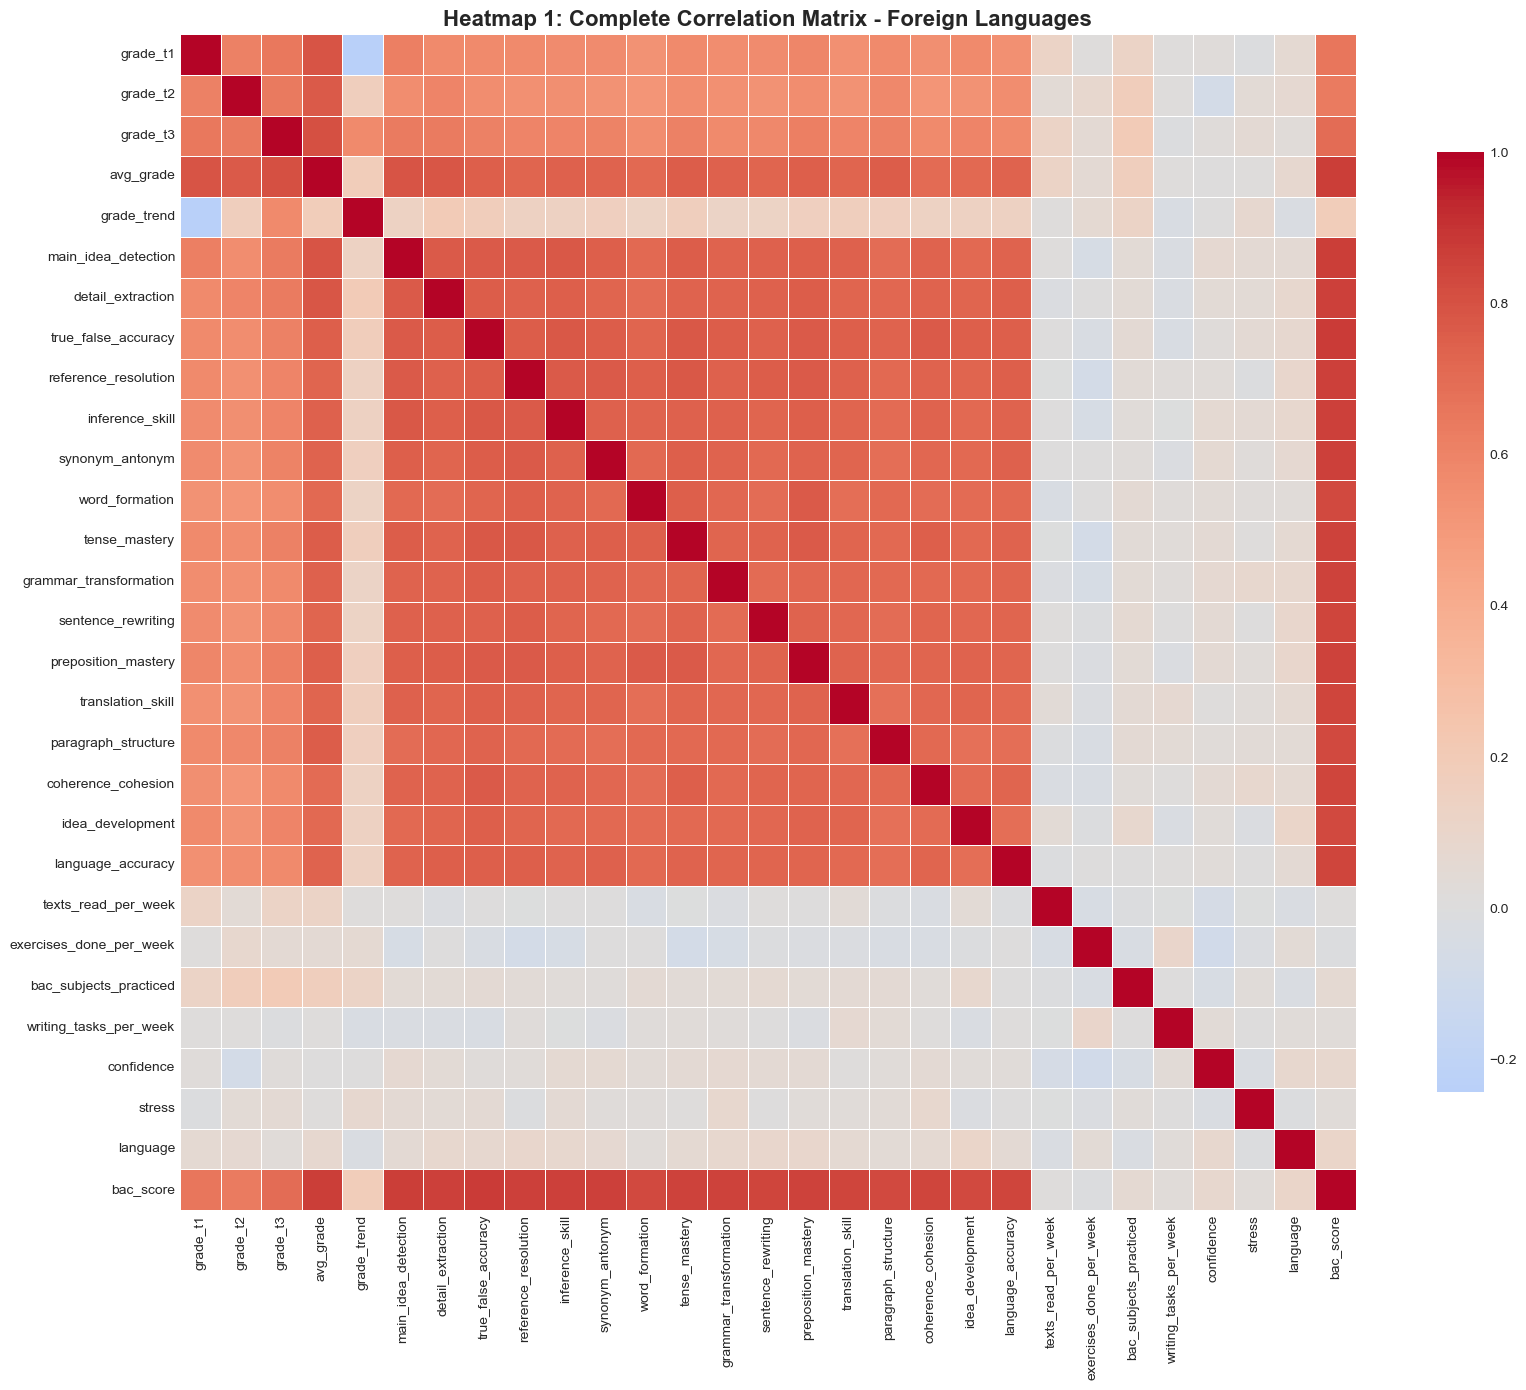


📊 HEATMAP 2: Top 15 Features Correlated with BAC Score


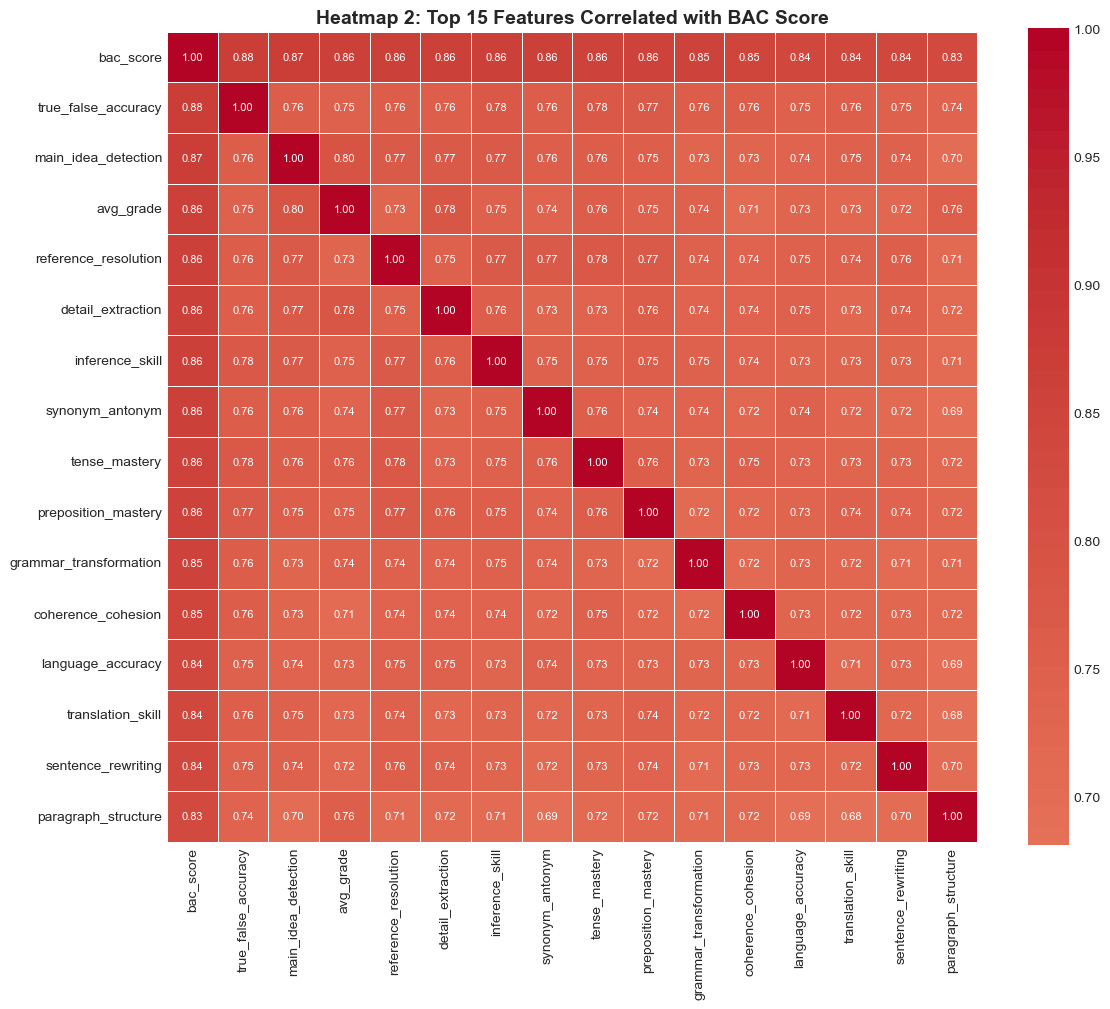


📊 HEATMAP 3: Core Skill Categories Correlation


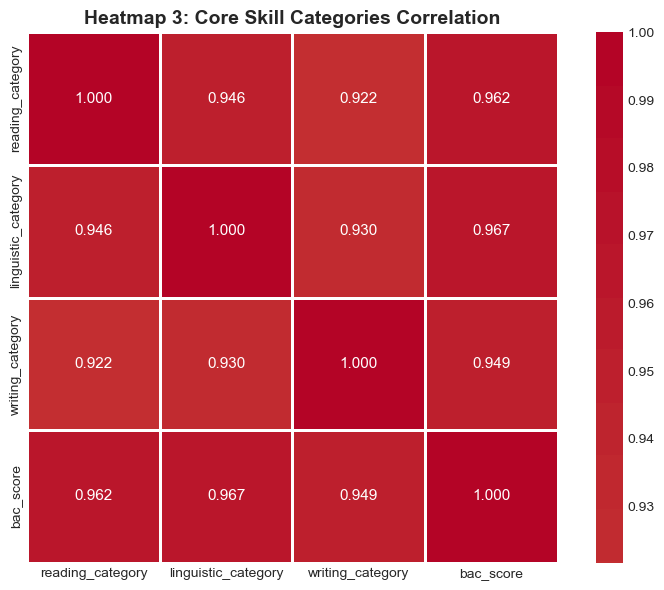


📊 HEATMAP 4: Remaining Features (Lower Correlation with BAC)


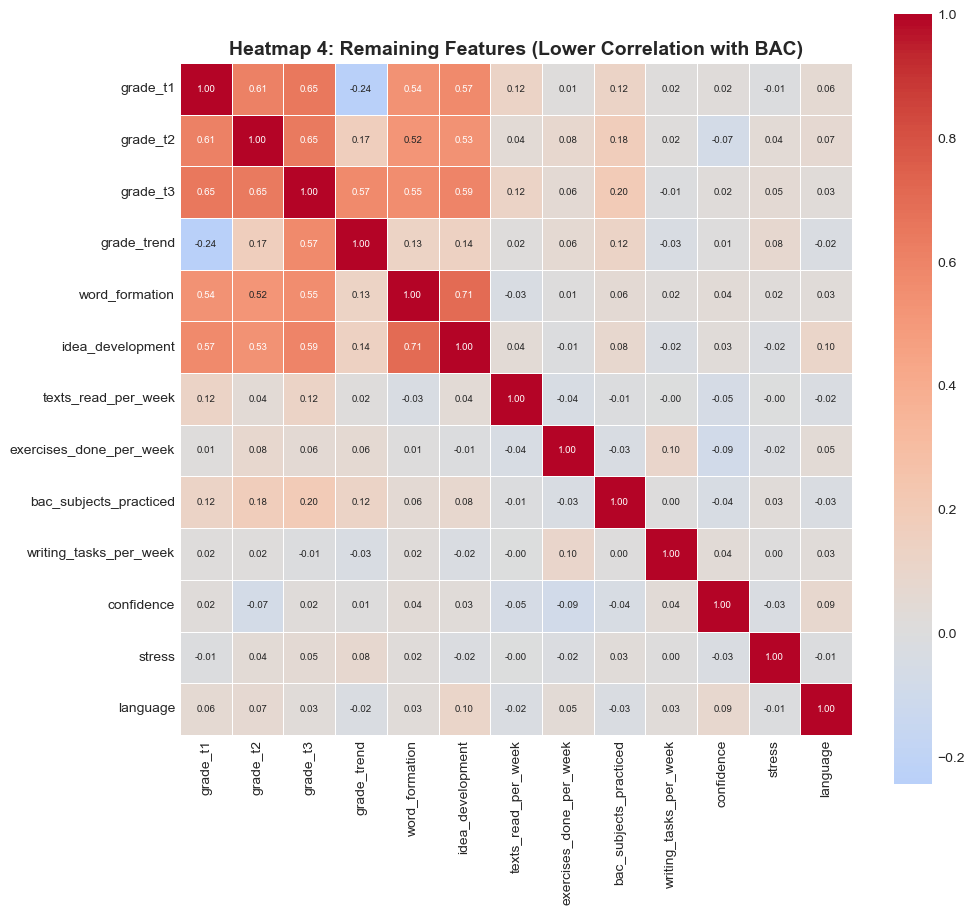


📋 Remaining features (13 features):
   • grade_t1: correlation = 0.661
   • grade_t2: correlation = 0.632
   • grade_t3: correlation = 0.698
   • grade_trend: correlation = 0.180
   • word_formation: correlation = 0.827
   • idea_development: correlation = 0.828
   • texts_read_per_week: correlation = 0.013
   • exercises_done_per_week: correlation = -0.008
   • bac_subjects_practiced: correlation = 0.058
   • writing_tasks_per_week: correlation = 0.033
   • confidence: correlation = 0.086
   • stress: correlation = 0.024
   • language: correlation = 0.102

✅ CORRELATION HEATMAPS COMPLETE


In [8]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS (FOREIGN LANGUAGES)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Correlation with BAC score
bac_corr = corr_matrix['bac_score'].sort_values(ascending=False)
print("\n" + "=" * 60)
print("📊 CORRELATION WITH BAC SCORE")
print("=" * 60)
print("(Highest to lowest)")
print("-" * 45)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:30s}: {corr_value:.3f}")

# ============================================
# HEATMAP 1: All Features
# ============================================
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap 1: Complete Correlation Matrix - Foreign Languages', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 2: Top 15 Features Correlated with BAC
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 2: Top 15 Features Correlated with BAC Score")
print("=" * 60)

# Get top 15 features (including bac_score itself)
top_features = bac_corr.head(16).index.tolist()
corr_top = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_top, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap 2: Top 15 Features Correlated with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 3: Reading, Linguistic, Writing Scores
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 3: Core Skill Categories Correlation")
print("=" * 60)

# Calculate category averages
df['reading_category'] = (df['main_idea_detection'] + df['detail_extraction'] + 
                          df['true_false_accuracy'] + df['reference_resolution'] + 
                          df['inference_skill']) / 5

df['linguistic_category'] = (df['synonym_antonym'] + df['word_formation'] + 
                             df['tense_mastery'] + df['grammar_transformation'] + 
                             df['sentence_rewriting'] + df['preposition_mastery'] + 
                             df['translation_skill']) / 7

df['writing_category'] = (df['paragraph_structure'] + df['coherence_cohesion'] + 
                          df['idea_development'] + df['language_accuracy']) / 4

# Correlation between categories
category_cols = ['reading_category', 'linguistic_category', 'writing_category', 'bac_score']
corr_categories = df[category_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_categories, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.3f',
            linewidths=1,
            annot_kws={'size': 11})
plt.title('Heatmap 3: Core Skill Categories Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 4: Remaining Features (Low Correlation)
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 4: Remaining Features (Lower Correlation with BAC)")
print("=" * 60)

top_feature_names = bac_corr.head(16).index.tolist()
remaining_features = [f for f in numeric_cols if f not in top_feature_names and f != 'bac_score' 
                      and f not in ['reading_category', 'linguistic_category', 'writing_category']]

if len(remaining_features) > 0:
    corr_remaining = df[remaining_features].corr()
    
    # Adjust figure size based on number of features
    fig_size = max(10, len(remaining_features) * 0.8)
    plt.figure(figsize=(fig_size, fig_size * 0.9))
    sns.heatmap(corr_remaining, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 7})
    plt.title('Heatmap 4: Remaining Features (Lower Correlation with BAC)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n📋 Remaining features ({len(remaining_features)} features):")
    for f in remaining_features[:20]:
        print(f"   • {f}: correlation = {bac_corr[f]:.3f}")
    if len(remaining_features) > 20:
        print(f"   ... and {len(remaining_features)-20} more")
else:
    print("   No remaining features to display")

# Clean up temporary columns
df = df.drop(['reading_category', 'linguistic_category', 'writing_category'], axis=1)

print("\n" + "=" * 60)
print("✅ CORRELATION HEATMAPS COMPLETE")
print("=" * 60)

In [3]:
# ============================================
# CELL 9: FEATURE ENGINEERING - DERIVED FEATURES (FOREIGN LANGUAGES)
# ============================================

print("=" * 60)
print("🔧 FEATURE ENGINEERING")
print("Creating derived features for Foreign Languages")
print("=" * 60)

# Create a copy of the dataframe
df_fe = df.copy()

# ============================================
# 1. Reading Score (average of reading comprehension skills)
# ============================================
reading_cols = ['main_idea_detection', 'detail_extraction', 'true_false_accuracy', 
                'reference_resolution', 'inference_skill']
reading_cols_exist = [col for col in reading_cols if col in df_fe.columns]
if reading_cols_exist:
    df_fe['reading_score'] = df_fe[reading_cols_exist].mean(axis=1)
    df_fe['reading_score'] = np.round(df_fe['reading_score'], 2)

# ============================================
# 2. Linguistic Score (average of language/grammar skills)
# ============================================
linguistic_cols = ['synonym_antonym', 'word_formation', 'tense_mastery', 
                   'grammar_transformation', 'sentence_rewriting', 
                   'preposition_mastery', 'translation_skill']
linguistic_cols_exist = [col for col in linguistic_cols if col in df_fe.columns]
if linguistic_cols_exist:
    df_fe['linguistic_score'] = df_fe[linguistic_cols_exist].mean(axis=1)
    df_fe['linguistic_score'] = np.round(df_fe['linguistic_score'], 2)

# ============================================
# 3. Writing Score (average of writing skills)
# ============================================
writing_cols = ['paragraph_structure', 'coherence_cohesion', 'idea_development', 'language_accuracy']
writing_cols_exist = [col for col in writing_cols if col in df_fe.columns]
if writing_cols_exist:
    df_fe['writing_score'] = df_fe[writing_cols_exist].mean(axis=1)
    df_fe['writing_score'] = np.round(df_fe['writing_score'], 2)

# ============================================
# 4. Practice Intensity (combines all practice activities)
# ============================================
practice_components = []
if 'writing_tasks_per_week' in df_fe.columns:
    practice_components.append(df_fe['writing_tasks_per_week'] * 2)  # 0-5 → 0-10
if 'texts_read_per_week' in df_fe.columns:
    practice_components.append(df_fe['texts_read_per_week'] * 1)      # 0-10 → 0-10
if 'bac_subjects_practiced' in df_fe.columns:
    practice_components.append(df_fe['bac_subjects_practiced'] / 2)   # 0-20 → 0-10
if 'exercises_done_per_week' in df_fe.columns:
    practice_components.append(df_fe['exercises_done_per_week'] / 2)  # 0-20 → 0-10

if practice_components:
    df_fe['practice_intensity'] = sum(practice_components) / len(practice_components)
    df_fe['practice_intensity'] = np.round(df_fe['practice_intensity'], 1)

# ============================================
# 5. Imbalance Score (variance between the 3 main skill areas)
# ============================================
skill_scores = []
if 'reading_score' in df_fe.columns:
    skill_scores.append('reading_score')
if 'linguistic_score' in df_fe.columns:
    skill_scores.append('linguistic_score')
if 'writing_score' in df_fe.columns:
    skill_scores.append('writing_score')

if len(skill_scores) >= 2:
    df_fe['imbalance_score'] = df_fe[skill_scores].var(axis=1)
    df_fe['imbalance_score'] = np.round(df_fe['imbalance_score'], 2)

# ============================================
# 6. Grammar Mastery (focus on core grammar skills)
# ============================================
grammar_cols = ['tense_mastery', 'grammar_transformation', 'sentence_rewriting']
grammar_cols_exist = [col for col in grammar_cols if col in df_fe.columns]
if grammar_cols_exist:
    df_fe['grammar_mastery'] = df_fe[grammar_cols_exist].mean(axis=1)
    df_fe['grammar_mastery'] = np.round(df_fe['grammar_mastery'], 2)

# ============================================
# 7. Vocabulary Score
# ============================================
vocab_cols = ['synonym_antonym', 'word_formation']
vocab_cols_exist = [col for col in vocab_cols if col in df_fe.columns]
if vocab_cols_exist:
    df_fe['vocabulary_score'] = df_fe[vocab_cols_exist].mean(axis=1)
    df_fe['vocabulary_score'] = np.round(df_fe['vocabulary_score'], 2)

# ============================================
# 8. Overall Proficiency
# ============================================
proficiency_components = []
if 'reading_score' in df_fe.columns:
    proficiency_components.append('reading_score')
if 'linguistic_score' in df_fe.columns:
    proficiency_components.append('linguistic_score')
if 'writing_score' in df_fe.columns:
    proficiency_components.append('writing_score')

if proficiency_components:
    df_fe['overall_proficiency'] = df_fe[proficiency_components].mean(axis=1)
    df_fe['overall_proficiency'] = np.round(df_fe['overall_proficiency'], 2)

# ============================================
# 9. Grade Stability (consistency across trimesters)
# ============================================
grade_variance = np.var([df_fe['grade_t1'], df_fe['grade_t2'], df_fe['grade_t3']], axis=0)
df_fe['grade_stability'] = 1 / (1 + grade_variance)
df_fe['grade_stability'] = np.clip(df_fe['grade_stability'], 0.3, 0.95)
df_fe['grade_stability'] = np.round(df_fe['grade_stability'], 2)

# ============================================
# 10. Psychological Balance
# ============================================
if 'confidence' in df_fe.columns and 'stress' in df_fe.columns:
    df_fe['psycho_balance'] = df_fe['confidence'] - df_fe['stress']
    df_fe['psycho_balance'] = np.clip(df_fe['psycho_balance'], -4, 4)

# ============================================
# 11. Study Efficiency
# ============================================
if 'study_hours' in df_fe.columns:
    df_fe['study_efficiency'] = df_fe['bac_score'] / (df_fe['study_hours'] + 1)
    df_fe['study_efficiency'] = np.round(df_fe['study_efficiency'], 2)
else:
    # Estimate study hours from practice intensity
    if 'practice_intensity' in df_fe.columns:
        df_fe['study_efficiency'] = df_fe['bac_score'] / (df_fe['practice_intensity'] + 1)
        df_fe['study_efficiency'] = np.round(df_fe['study_efficiency'], 2)

# ============================================
# Display new features
# ============================================
new_features = [f for f in [
    'reading_score', 'linguistic_score', 'writing_score',
    'practice_intensity', 'imbalance_score', 'grammar_mastery',
    'vocabulary_score', 'overall_proficiency', 'grade_stability', 
    'psycho_balance', 'study_efficiency'
] if f in df_fe.columns]

print("\n✅ New derived features created:")
for f in new_features:
    print(f"   • {f}")

print("\n📊 Preview of derived features (first 5 rows):")
preview_cols = ['bac_score'] + new_features[:5]
print(df_fe[preview_cols].head())

print("\n📊 Derived features statistics:")
print(df_fe[new_features].describe().round(2))

# ============================================
# Replace the original dataframe
# ============================================
df = df_fe.copy()

print("\n✅ Feature engineering complete!")
print(f"   Total columns: {df.shape[1]}")
print("=" * 60)

🔧 FEATURE ENGINEERING
Creating derived features for Foreign Languages

✅ New derived features created:
   • reading_score
   • linguistic_score
   • writing_score
   • practice_intensity
   • imbalance_score
   • grammar_mastery
   • vocabulary_score
   • overall_proficiency
   • grade_stability
   • psycho_balance
   • study_efficiency

📊 Preview of derived features (first 5 rows):
   bac_score  reading_score  linguistic_score  writing_score  practice_intensity  imbalance_score
0       13.9           7.74              6.63           7.80                 1.8             0.43
1       12.3           6.80              5.64           5.28                 3.0             0.63
2       14.3           6.94              6.67           7.58                 5.2             0.22
3       16.2           8.62              8.60           8.35                 3.2             0.02
4       12.5           5.64              5.79           6.38                 2.6             0.15

📊 Derived features statis

In [4]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT (FOREIGN LANGUAGES)
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("📊 TRAIN/TEST SPLIT")
print("=" * 60)

# ============================================
# Define features (X) and target (y)
# ============================================

# Exclude target and non-predictive columns
exclude_cols = ['bac_score', 'grade_trend', 'grade_stability']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['bac_score']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score")

# Display feature categories
print("\n📋 Feature categories:")
categories = {
    'Academic History': ['grade_t1', 'grade_t2', 'grade_t3', 'avg_grade'],
    'Reading Skills': ['main_idea_detection', 'detail_extraction', 'true_false_accuracy', 
                       'reference_resolution', 'inference_skill'],
    'Linguistic Skills': ['synonym_antonym', 'word_formation', 'tense_mastery',
                          'grammar_transformation', 'sentence_rewriting', 
                          'preposition_mastery', 'translation_skill'],
    'Writing Skills': ['paragraph_structure', 'coherence_cohesion', 'idea_development', 'language_accuracy'],
    'Practice & Habits': ['texts_read_per_week', 'exercises_done_per_week', 
                          'bac_subjects_practiced', 'writing_tasks_per_week'],
    'Psychological': ['confidence', 'stress'],
    'Context': ['language'],
    'Derived Features': ['reading_score', 'linguistic_score', 'writing_score', 'practice_intensity',
                         'imbalance_score', 'grammar_mastery', 'vocabulary_score', 
                         'overall_proficiency', 'psycho_balance', 'study_efficiency']
}

for category, features in categories.items():
    present = [f for f in features if f in feature_cols]
    print(f"   {category}: {len(present)} features")

# ============================================
# Split data (80% train, 20% test)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)")

# ============================================
# Display first few rows
# ============================================
print("\n📋 First 3 rows of training features:")
print(X_train.head(3).to_string())

print("\n📋 First 3 target values (bac_score):")
print(y_train.head(3).tolist())

# ============================================
# Verify no data leakage
# ============================================
print("\n✅ No overlap between train and test:")
print(f"   Train indices: {X_train.index[:5].tolist()}...")
print(f"   Test indices:  {X_test.index[:5].tolist()}...")

# ============================================
# Language distribution in train/test
# ============================================
print("\n📋 Language distribution in splits:")
for split_name, split_data in [('Train', X_train), ('Test', X_test)]:
    print(f"\n   {split_name} set:")
    for lang_code in [0, 1, 2]:
        lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[lang_code]
        # Get language from original df using indices
        lang_count = (df.loc[split_data.index, 'language'] == lang_code).sum()
        print(f"      {lang_name}: {lang_count} students ({lang_count/len(split_data)*100:.1f}%)")

print("\n" + "=" * 60)
print("✅ Train/Test Split Complete")
print("=" * 60)

📊 TRAIN/TEST SPLIT

📊 Features (X): 37 columns
📊 Target (y): bac_score

📋 Feature categories:
   Academic History: 4 features
   Reading Skills: 5 features
   Linguistic Skills: 7 features
   Writing Skills: 4 features
   Practice & Habits: 4 features
   Psychological: 2 features
   Context: 1 features
   Derived Features: 10 features

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

📋 First 3 rows of training features:
     grade_t1  grade_t2  grade_t3  avg_grade  main_idea_detection  detail_extraction  true_false_accuracy  reference_resolution  inference_skill  synonym_antonym  word_formation  tense_mastery  grammar_transformation  sentence_rewriting  preposition_mastery  translation_skill  paragraph_structure  coherence_cohesion  idea_development  language_accuracy  texts_read_per_week  exercises_done_per_week  bac_subjects_practiced  writing_tasks_per_week  confidence  stress  language  reading_score  linguistic_score  writing_score  practi

In [5]:
# ============================================
# CELL 11: MODEL TRAINING - RANDOM FOREST (FOREIGN LANGUAGES)
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 60)
print("🤖 MODEL TRAINING - RANDOM FOREST")
print("=" * 60)

# ============================================
# Prepare multi-output targets
# ============================================

# For multi-output, we need 3 targets:
# 1. predicted_score (BAC score)
# 2. success_probability (probability of getting >= 10)
# 3. improvement_potential (how many points can be gained)

y_train_multi = np.zeros((len(y_train), 3))
y_test_multi = np.zeros((len(y_test), 3))

# Target 1: Actual BAC score
y_train_multi[:, 0] = y_train.values
y_test_multi[:, 0] = y_test.values

# Target 2: Success probability (1 if score >= 10, else 0)
y_train_multi[:, 1] = (y_train >= 10).astype(int)
y_test_multi[:, 1] = (y_test >= 10).astype(int)

# Target 3: Improvement potential (how far from 18)
y_train_multi[:, 2] = 18 - y_train.values
y_test_multi[:, 2] = 18 - y_test.values
y_train_multi[:, 2] = np.clip(y_train_multi[:, 2], 0, 10)
y_test_multi[:, 2] = np.clip(y_test_multi[:, 2], 0, 10)

print(f"\n📊 Multi-output targets created:")
print(f"   Output 1: predicted_score (0-20)")
print(f"   Output 2: success_probability (0 or 1)")
print(f"   Output 3: improvement_potential (0-10)")

# ============================================
# Train Random Forest Multi-output model
# ============================================

print(f"\n🚀 Training Random Forest Multi-output Regressor...")

base_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model = MultiOutputRegressor(base_model)

model.fit(X_train, y_train_multi)

print(f"✅ Model training complete!")

# ============================================
# Make predictions
# ============================================
y_pred_multi = model.predict(X_test)

# Extract individual predictions
y_pred_score = y_pred_multi[:, 0]
y_pred_prob = y_pred_multi[:, 1]
y_pred_improve = y_pred_multi[:, 2]

# ============================================
# Evaluate each output
# ============================================
print("\n" + "=" * 60)
print("📊 MODEL EVALUATION")
print("=" * 60)

# Output 1: Score prediction
mae_score = mean_absolute_error(y_test, y_pred_score)
rmse_score = np.sqrt(mean_squared_error(y_test, y_pred_score))
r2_score_val = r2_score(y_test, y_pred_score)

print(f"\n📊 Output 1: Predicted BAC Score (0-20)")
print(f"   MAE:  {mae_score:.2f} points")
print(f"   RMSE: {rmse_score:.2f} points")
print(f"   R²:   {r2_score_val:.3f}")

# Output 2: Success probability
from sklearn.metrics import accuracy_score

y_pred_class = (y_pred_prob >= 0.5).astype(int)
acc_score = accuracy_score(y_test_multi[:, 1], y_pred_class)

print(f"\n📊 Output 2: Success Probability (≥10/20)")
print(f"   Accuracy: {acc_score:.3f} ({acc_score*100:.1f}%)")

# Output 3: Improvement potential
mae_improve = mean_absolute_error(y_test_multi[:, 2], y_pred_improve)
print(f"\n📊 Output 3: Improvement Potential (0-10)")
print(f"   MAE: {mae_improve:.2f} points")

# ============================================
# Feature Importance
# ============================================
print("\n" + "=" * 60)
print("📊 FEATURE IMPORTANCE")
print("=" * 60)

# Get feature importance from first estimator
feature_importance = model.estimators_[0].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 20 most important features:")
for i, row in feature_importance_df.head(20).iterrows():
    print(f"   {row['feature']:35s}: {row['importance']:.4f} ({row['importance']*100:.1f}%)")

# ============================================
# Sample predictions vs actual
# ============================================
print("\n" + "=" * 60)
print("📊 SAMPLE PREDICTIONS (First 15 test students)")
print("=" * 60)

sample_df = pd.DataFrame({
    'Actual': y_test.values[:15],
    'Predicted': np.round(y_pred_score[:15], 1),
    'Error': np.round(y_test.values[:15] - y_pred_score[:15], 1)
})
print(sample_df.to_string())

# ============================================
# Performance by language
# ============================================
print("\n" + "=" * 60)
print("📊 PERFORMANCE BY LANGUAGE")
print("=" * 60)

for lang_code in [0, 1, 2]:
    lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[lang_code]
    # Get indices where language matches
    lang_indices = df.loc[X_test.index, 'language'] == lang_code
    if lang_indices.sum() > 0:
        mae_lang = mean_absolute_error(y_test[lang_indices], y_pred_score[lang_indices])
        print(f"   {lang_name}: {lang_indices.sum()} students, MAE = {mae_lang:.3f} points")

print("\n" + "=" * 60)
print("✅ Model Training Complete")
print("=" * 60)

🤖 MODEL TRAINING - RANDOM FOREST

📊 Multi-output targets created:
   Output 1: predicted_score (0-20)
   Output 2: success_probability (0 or 1)
   Output 3: improvement_potential (0-10)

🚀 Training Random Forest Multi-output Regressor...
✅ Model training complete!

📊 MODEL EVALUATION

📊 Output 1: Predicted BAC Score (0-20)
   MAE:  0.39 points
   RMSE: 0.48 points
   R²:   0.966

📊 Output 2: Success Probability (≥10/20)
   Accuracy: 0.980 (98.0%)

📊 Output 3: Improvement Potential (0-10)
   MAE: 0.38 points

📊 FEATURE IMPORTANCE

Top 20 most important features:
   overall_proficiency                : 0.9483 (94.8%)
   linguistic_score                   : 0.0124 (1.2%)
   reading_score                      : 0.0065 (0.7%)
   avg_grade                          : 0.0042 (0.4%)
   grammar_mastery                    : 0.0023 (0.2%)
   vocabulary_score                   : 0.0016 (0.2%)
   imbalance_score                    : 0.0014 (0.1%)
   grammar_transformation             : 0.0013 (0.1%)

📊 DETAILED MODEL EVALUATION

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     0.395 points
   Mean Squared Error (MSE):      0.231
   Root Mean Squared Error (RMSE): 0.481 points
   R² Score:                      0.966

----------------------------------------
2. SUCCESS CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy:  0.980 (98.0%)

   Confusion Matrix:
   -----------------
   True Negatives (fail):  12
   False Positives:        1
   False Negatives:        1
   True Positives (pass):  86

   Classification Report:
   ---------------------
              precision    recall  f1-score   support

  Fail (<10)       0.92      0.92      0.92        13
  Pass (≥10)       0.99      0.99      0.99        87

    accuracy                           0.98       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.98      0.98      0.98       100




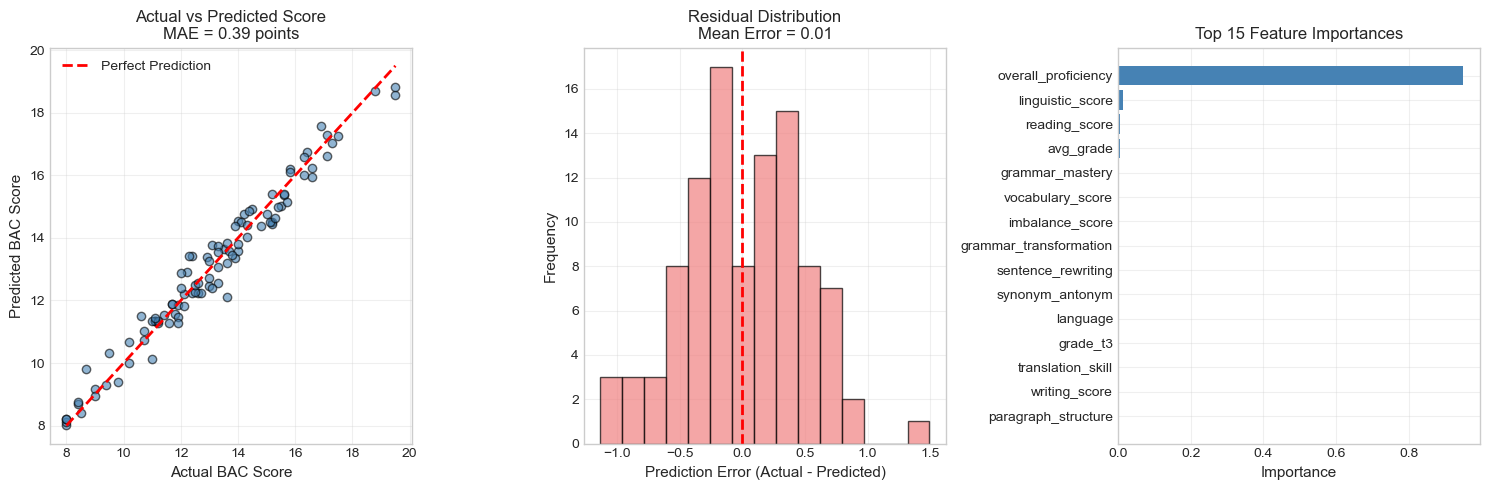


----------------------------------------
4. ERROR SUMMARY
----------------------------------------
   Mean Error:      0.395 points
   Median Error:    0.333 points
   Max Error:       1.494 points
   Error < 1 point: 96.0% of predictions
   Error < 2 points: 100.0% of predictions

----------------------------------------
5. PERFORMANCE BY SCORE RANGE
----------------------------------------
   <10      ( 13 students): MAE = 0.301 points
   10-12    ( 22 students): MAE = 0.346 points
   12-14    ( 32 students): MAE = 0.439 points
   14-16    ( 20 students): MAE = 0.419 points
   16-20    ( 13 students): MAE = 0.427 points

----------------------------------------
6. PERFORMANCE BY LANGUAGE
----------------------------------------

   Spanish (40 students):
      MAE: 0.379 points
      R²:  0.969

   German (23 students):
      MAE: 0.376 points
      R²:  0.977

   Italian (37 students):
      MAE: 0.424 points
      R²:  0.953

✅ DETAILED EVALUATION COMPLETE


In [6]:
# ============================================
# CELL 12: DETAILED MODEL EVALUATION (FOREIGN LANGUAGES)
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("📊 DETAILED MODEL EVALUATION")
print("=" * 60)

# ============================================
# 1. Score Prediction Metrics
# ============================================
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred_score)
mse = mean_squared_error(y_test, y_pred_score)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_score)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Mean Squared Error (MSE):      {mse:.3f}")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# ============================================
# 2. Success Classification
# ============================================
print("\n" + "-" * 40)
print("2. SUCCESS CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
print("   -----------------")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (fail):  {cm[0][0]}")
print(f"   False Positives:        {cm[0][1]}")
print(f"   False Negatives:        {cm[1][0]}")
print(f"   True Positives (pass):  {cm[1][1]}")

print("\n   Classification Report:")
print("   ---------------------")
print(classification_report(y_true_class, y_pred_class, target_names=['Fail (<10)', 'Pass (≥10)']))

# ============================================
# 3. Improvement Potential Metrics
# ============================================
print("\n" + "-" * 40)
print("3. IMPROVEMENT POTENTIAL")
print("-" * 40)

mae_improve = mean_absolute_error(y_test_multi[:, 2], y_pred_improve)
print(f"   MAE: {mae_improve:.3f} points")

# ============================================
# 4. Visualizations
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Actual vs Predicted Score
axes[0].scatter(y_test, y_pred_score, alpha=0.6, color='steelblue', edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual BAC Score', fontsize=11)
axes[0].set_ylabel('Predicted BAC Score', fontsize=11)
axes[0].set_title(f'Actual vs Predicted Score\nMAE = {mae:.2f} points', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (Error Distribution)
residuals = y_test - y_pred_score
axes[1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[1].set_xlabel('Prediction Error (Actual - Predicted)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 15)
feature_importance = model.estimators_[0].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=True).tail(15)

axes[2].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
axes[2].set_xlabel('Importance', fontsize=11)
axes[2].set_title('Top 15 Feature Importances', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 5. Error Summary
# ============================================
print("\n" + "-" * 40)
print("4. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred_score)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Max Error:       {errors.max():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

# ============================================
# 6. Performance by Score Range
# ============================================
print("\n" + "-" * 40)
print("5. PERFORMANCE BY SCORE RANGE")
print("-" * 40)

bins = [0, 10, 12, 14, 16, 20]
labels = ['<10', '10-12', '12-14', '14-16', '16-20']
y_test_binned = pd.cut(y_test, bins=bins, labels=labels)

for label in labels:
    mask = y_test_binned == label
    if mask.sum() > 0:
        mae_slice = mean_absolute_error(y_test[mask], y_pred_score[mask])
        print(f"   {label:8s} ({mask.sum():3d} students): MAE = {mae_slice:.3f} points")

# ============================================
# 7. Performance by Language
# ============================================
print("\n" + "-" * 40)
print("6. PERFORMANCE BY LANGUAGE")
print("-" * 40)

language_names = {0: 'Spanish', 1: 'German', 2: 'Italian'}

for lang_code, lang_name in language_names.items():
    lang_indices = df.loc[X_test.index, 'language'] == lang_code
    if lang_indices.sum() > 0:
        mae_lang = mean_absolute_error(y_test[lang_indices], y_pred_score[lang_indices])
        r2_lang = r2_score(y_test[lang_indices], y_pred_score[lang_indices])
        print(f"\n   {lang_name} ({lang_indices.sum()} students):")
        print(f"      MAE: {mae_lang:.3f} points")
        print(f"      R²:  {r2_lang:.3f}")

print("\n" + "=" * 60)
print("✅ DETAILED EVALUATION COMPLETE")
print("=" * 60)

🔍 SHAP EXPLAINABILITY
Explaining individual predictions

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 37)


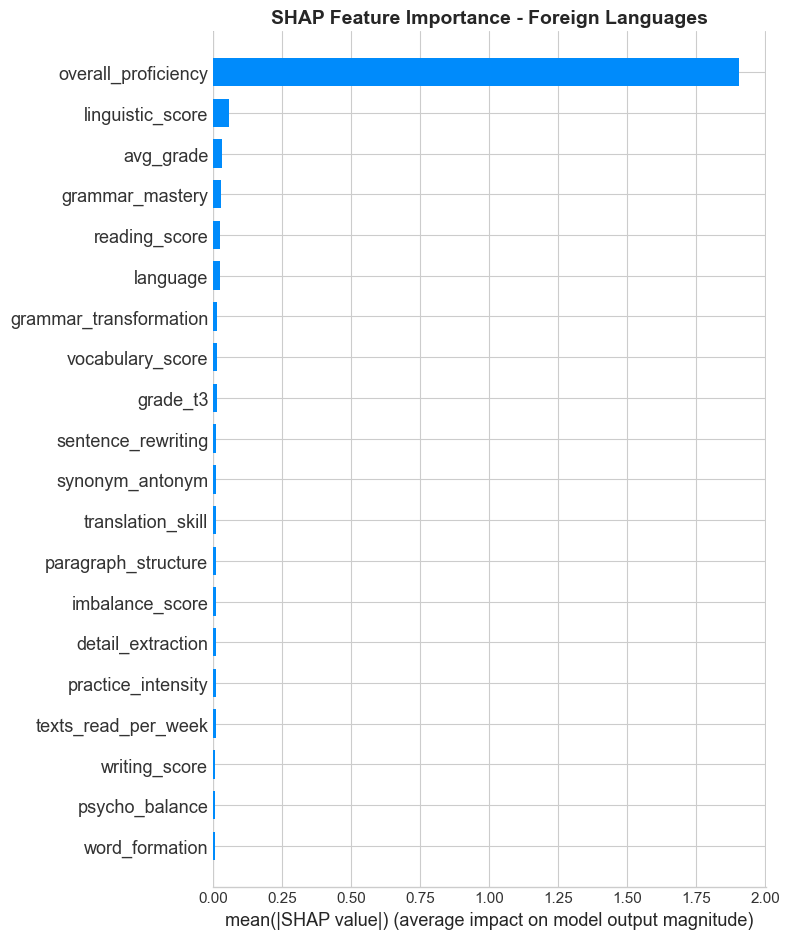

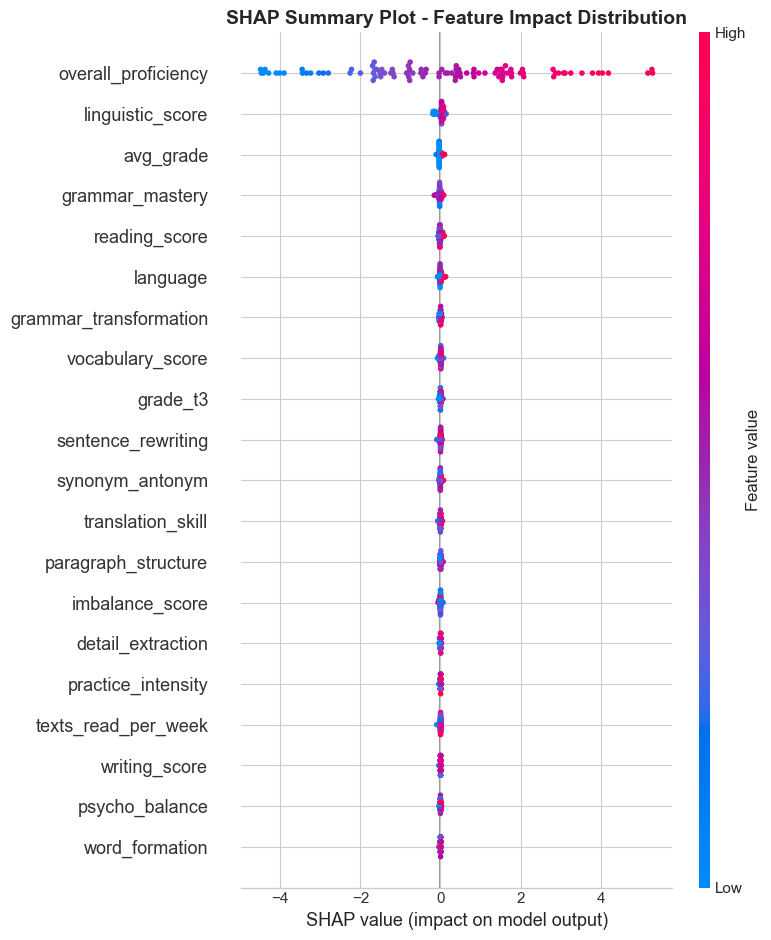


📊 SINGLE STUDENT EXPLANATION

👤 Student #0 (Italian):
   Actual BAC score: 16.9
   Predicted BAC score: 17.6


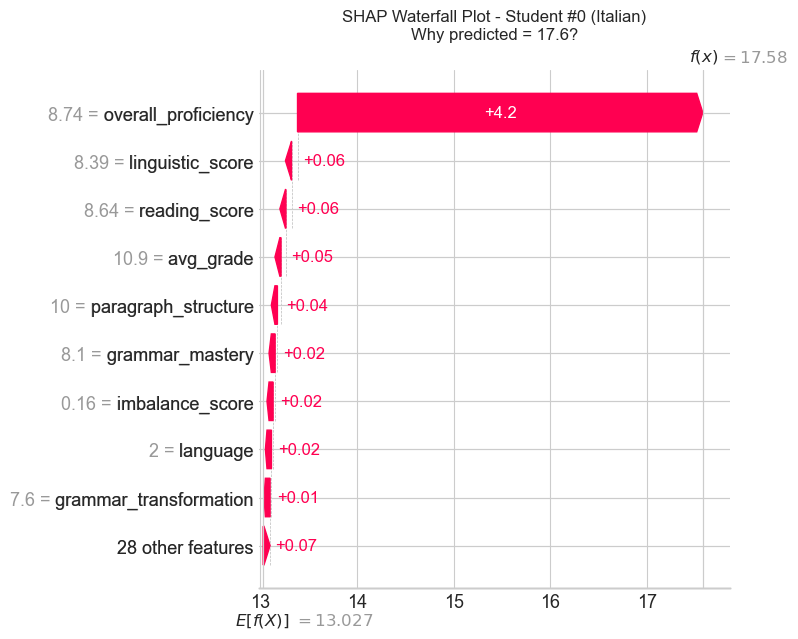


📖 SIMPLE EXPLANATION FOR STUDENT

✅ Predicted score: 17.6/20
   Actual score: 16.9/20

🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):
   • synonym_antonym: -0.01 points
   • confidence: -0.00 points
   • reference_resolution: -0.00 points
   • exercises_done_per_week: -0.00 points
   • detail_extraction: -0.00 points

🟢 FACTORS THAT RAISED THE SCORE (Strengths):
   • overall_proficiency: +4.20 points
   • linguistic_score: +0.06 points
   • reading_score: +0.06 points
   • avg_grade: +0.05 points
   • paragraph_structure: +0.04 points

📊 EXPLANATION BY SKILL CATEGORY

📊 Impact by skill category (higher = more important for this student):
   Linguistic Skills   : ██ (0.15)
   Reading Skills      : █ (0.07)
   Academic            : █ (0.07)
   Writing Skills      :  (0.05)
   Practice & Habits   :  (0.03)
   Context             :  (0.02)
   Psychological       :  (0.01)

✅ SHAP values saved to 'shap_values_foreign.csv'

✅ SHAP Explainability Complete


In [7]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY (FOREIGN LANGUAGES)
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 60)
print("🔍 SHAP EXPLAINABILITY")
print("Explaining individual predictions")
print("=" * 60)

# ============================================
# Create SHAP explainer
# ============================================
print("\n📊 Creating SHAP explainer...")

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(model.estimators_[0])  # First estimator for score prediction
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {np.array(shap_values).shape}")

# ============================================
# Visualization 1: Feature Importance (SHAP)
# ============================================
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Foreign Languages', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# Visualization 2: Summary Plot (Beeswarm)
# ============================================
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# Visualization 3: Single Student Explanation
# ============================================
print("\n" + "=" * 60)
print("📊 SINGLE STUDENT EXPLANATION")
print("=" * 60)

# Pick a student from test set
student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = y_pred_score[student_idx]

# Get language of this student
student_lang_code = df.loc[X_test.index[student_idx], 'language']
student_lang = {0: 'Spanish', 1: 'German', 2: 'Italian'}[student_lang_code]

print(f"\n👤 Student #{student_idx} ({student_lang}):")
print(f"   Actual BAC score: {student_actual:.1f}")
print(f"   Predicted BAC score: {student_pred:.1f}")

# Create waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx} ({student_lang})\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# Simple explanation for student
# ============================================
print("\n" + "=" * 60)
print("📖 SIMPLE EXPLANATION FOR STUDENT")
print("=" * 60)

# Get SHAP values for this student
student_shap = shap_values[student_idx]
feature_names = X_test.columns.tolist()

# Create DataFrame with contributions
shap_df_student = pd.DataFrame({
    'feature': feature_names,
    'shap_value': student_shap
})
shap_df_student['absolute'] = np.abs(shap_df_student['shap_value'])
shap_df_student = shap_df_student.sort_values('absolute', ascending=False)

# Separate positive and negative
positive = shap_df_student[shap_df_student['shap_value'] > 0].head(5)
negative = shap_df_student[shap_df_student['shap_value'] < 0].head(5)

print(f"\n✅ Predicted score: {student_pred:.1f}/20")
print(f"   Actual score: {student_actual:.1f}/20")

print(f"\n🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):")
if len(negative) > 0:
    for _, row in negative.iterrows():
        print(f"   • {row['feature']}: -{abs(row['shap_value']):.2f} points")
else:
    print("   • None - this student has no major weaknesses!")

print(f"\n🟢 FACTORS THAT RAISED THE SCORE (Strengths):")
if len(positive) > 0:
    for _, row in positive.iterrows():
        print(f"   • {row['feature']}: +{row['shap_value']:.2f} points")
else:
    print("   • None")

# ============================================
# Explanation by feature category
# ============================================
print("\n" + "=" * 60)
print("📊 EXPLANATION BY SKILL CATEGORY")
print("=" * 60)

# Categorize features
categories = {
    'Reading Skills': ['main_idea_detection', 'detail_extraction', 'true_false_accuracy', 
                       'reference_resolution', 'inference_skill', 'reading_score'],
    'Linguistic Skills': ['synonym_antonym', 'word_formation', 'tense_mastery', 'grammar_transformation',
                          'sentence_rewriting', 'preposition_mastery', 'translation_skill', 
                          'linguistic_score', 'grammar_mastery', 'vocabulary_score'],
    'Writing Skills': ['paragraph_structure', 'coherence_cohesion', 'idea_development', 
                       'language_accuracy', 'writing_score'],
    'Practice & Habits': ['texts_read_per_week', 'exercises_done_per_week', 'bac_subjects_practiced',
                          'writing_tasks_per_week', 'practice_intensity', 'study_efficiency'],
    'Psychological': ['confidence', 'stress', 'psycho_balance'],
    'Academic': ['grade_t1', 'grade_t2', 'grade_t3', 'avg_grade'],
    'Context': ['language']
}

category_contributions = {}
for category, cat_features in categories.items():
    total = 0
    for feat in cat_features:
        if feat in feature_names:
            feat_idx = feature_names.index(feat)
            total += abs(student_shap[feat_idx])
    if total > 0:
        category_contributions[category] = total

# Sort by contribution
sorted_cats = sorted(category_contributions.items(), key=lambda x: x[1], reverse=True)

print("\n📊 Impact by skill category (higher = more important for this student):")
for cat, contrib in sorted_cats:
    bar_len = int(contrib * 20)
    print(f"   {cat:20s}: {'█' * bar_len} ({contrib:.2f})")

# ============================================
# Save SHAP values
# ============================================
shap_df_all = pd.DataFrame(shap_values, columns=feature_names)
shap_df_all.to_csv('shap_values_foreign.csv', index=False)
print("\n✅ SHAP values saved to 'shap_values_foreign.csv'")

print("\n" + "=" * 60)
print("✅ SHAP Explainability Complete")
print("=" * 60)

In [8]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS (FOREIGN LANGUAGES)
# ============================================

import pandas as pd
import numpy as np
from collections import Counter

print("=" * 60)
print("📊 WEAKNESS ANALYSIS")
print("Analyzing student weaknesses and strengths")
print("=" * 60)

# ============================================
# Use SHAP values to identify weaknesses
# ============================================

# Get feature names and SHAP values from Cell 13
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values for all test students
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

# ============================================
# For each student, identify top 3 weaknesses and top 3 strengths
# ============================================

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Get negative contributions (weaknesses)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Get positive contributions (strengths)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    # Get student's language
    student_lang_code = df.loc[X_test.index[i], 'language']
    student_lang = {0: 'Spanish', 1: 'German', 2: 'Italian'}[student_lang_code]
    
    weakness_list.append({
        'student_id': i,
        'language': student_lang,
        'weakness_1': f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None",
        'weakness_2': f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None",
        'weakness_3': f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None",
        'strength_1': f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None",
        'strength_2': f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None",
        'strength_3': f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None",
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred_score[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# ============================================
# Display first 15 students
# ============================================
print("\n📋 FIRST 15 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(15, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1} ({row['language']}): Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses:")
    print(f"      • {row['weakness_1']}")
    print(f"      • {row['weakness_2']}")
    print(f"      • {row['weakness_3']}")
    print(f"   🟢 Strengths:")
    print(f"      • {row['strength_1']}")
    print(f"      • {row['strength_2']}")
    print(f"      • {row['strength_3']}")

# ============================================
# Most common weaknesses across all students
# ============================================
print("\n" + "=" * 60)
print("📊 MOST COMMON WEAKNESSES (All Students)")
print("=" * 60)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 15 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(15):
    print(f"   • {feature}: {count} students")

# ============================================
# Weaknesses by language
# ============================================
print("\n" + "=" * 60)
print("📊 WEAKNESSES BY LANGUAGE")
print("=" * 60)

for lang_code in [0, 1, 2]:
    lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[lang_code]
    lang_weaknesses = []
    
    for i in range(len(weakness_df)):
        if weakness_df.iloc[i]['language'] == lang_name:
            for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
                if w != "None":
                    feature_name = w.split(' (')[0]
                    lang_weaknesses.append(feature_name)
    
    lang_counts = Counter(lang_weaknesses)
    print(f"\n📖 {lang_name}:")
    for feature, count in lang_counts.most_common(5):
        print(f"   • {feature}: {count} students")

# ============================================
# Generate actionable recommendations
# ============================================
print("\n" + "=" * 60)
print("📋 ACTIONABLE RECOMMENDATIONS")
print("=" * 60)

# Map features to recommendations
recommendation_map = {
    # Reading Skills
    'main_idea_detection': '📖 Practice identifying the main idea of texts',
    'detail_extraction': '🔍 Practice finding specific information in texts',
    'true_false_accuracy': '✓✗ Practice true/false questions with justification',
    'reference_resolution': '🔗 Practice identifying what pronouns (it/they/this) refer to',
    'inference_skill': '🎯 Practice reading between the lines and making inferences',
    'reading_score': '📖 Improve your overall reading comprehension',
    
    # Linguistic Skills
    'synonym_antonym': '📚 Learn synonyms and antonyms - use a thesaurus',
    'word_formation': '🔤 Practice prefixes and suffixes (un-, re-, -ment, -tion)',
    'tense_mastery': '⏰ Review past, present, and perfect tenses',
    'grammar_transformation': '✍️ Practice transforming sentences (active/passive, direct/indirect)',
    'sentence_rewriting': '📝 Practice rewriting sentences in different structures',
    'preposition_mastery': '📍 Learn common preposition combinations (interested in, good at)',
    'translation_skill': '🌐 Practice translating sentences from/to your target language',
    'linguistic_score': '📚 Improve your grammar and vocabulary skills',
    'grammar_mastery': '📖 Focus on core grammar rules and exceptions',
    'vocabulary_score': '📚 Learn 10 new words daily and review weekly',
    
    # Writing Skills
    'paragraph_structure': '📋 Use introduction, body, and conclusion in your paragraphs',
    'coherence_cohesion': '🔗 Use linking words (however, therefore, moreover)',
    'idea_development': '💡 Develop your ideas with examples and explanations',
    'language_accuracy': '📖 Review grammar and spelling in your writing',
    'writing_score': '✍️ Practice writing essays regularly',
    
    # Practice & Habits
    'texts_read_per_week': '📖 Read more texts in your target language',
    'exercises_done_per_week': '📝 Do more grammar and vocabulary exercises',
    'bac_subjects_practiced': '📚 Solve past BAC exams regularly',
    'writing_tasks_per_week': '✍️ Write more essays and paragraphs',
    'practice_intensity': '⚡ Increase your practice frequency',
    'study_efficiency': '⏰ Use your study time more effectively',
    
    # Psychological
    'confidence': '💪 Build confidence by starting with easier exercises',
    'stress': '🧘 Practice relaxation techniques before exams',
    'psycho_balance': '⚖️ Work on reducing stress and building confidence',
    
    # Academic
    'grade_t1': '📊 Improve your first trimester performance',
    'grade_t2': '📊 Improve your second trimester performance',
    'grade_t3': '📊 Improve your third trimester performance',
    'avg_grade': '📊 Focus on improving your overall average'
}

# Get unique weaknesses and their recommendations
unique_weaknesses = set(all_weaknesses)
print("\n📋 Personalized Recommendations based on common weaknesses:")
for weakness in list(unique_weaknesses)[:20]:
    if weakness in recommendation_map:
        print(f"   • {recommendation_map[weakness]}")
    else:
        # Try to find by keyword
        if 'reading' in weakness or 'main_idea' in weakness or 'inference' in weakness:
            print(f"   • 📖 Improve your reading comprehension skills")
        elif 'writing' in weakness or 'paragraph' in weakness or 'essay' in weakness:
            print(f"   • ✍️ Practice writing essays regularly")
        elif 'grammar' in weakness or 'tense' in weakness or 'transformation' in weakness:
            print(f"   • 📚 Review grammar rules and do exercises")
        elif 'vocabulary' in weakness or 'synonym' in weakness or 'antonym' in weakness:
            print(f"   • 📖 Expand your vocabulary - learn new words daily")
        elif 'practice' in weakness or 'bac' in weakness or 'exercises' in weakness:
            print(f"   • 📚 Solve more past BAC exams")
        elif 'confidence' in weakness:
            print(f"   • 💪 Build confidence with easier exercises first")
        elif 'grade' in weakness:
            print(f"   • 📊 Work on improving your grades")
        else:
            print(f"   • {weakness}: Focus on improving this area")

# ============================================
# Save weakness analysis to CSV
# ============================================
weakness_df.to_csv('weakness_analysis_foreign.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_foreign.csv'")

print("\n" + "=" * 60)
print("✅ Weakness Analysis Complete")
print("=" * 60)

📊 WEAKNESS ANALYSIS
Analyzing student weaknesses and strengths

📊 Analyzing weaknesses for each student...

📋 FIRST 15 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1 (Italian): Actual=16.9, Predicted=17.6
   🔴 Weaknesses:
      • synonym_antonym (-0.01)
      • confidence (-0.00)
      • reference_resolution (-0.00)
   🟢 Strengths:
      • overall_proficiency (+4.20)
      • linguistic_score (+0.06)
      • reading_score (+0.06)

🔹 STUDENT 2 (Spanish): Actual=17.5, Predicted=17.3
   🔴 Weaknesses:
      • imbalance_score (-0.03)
      • avg_grade (-0.02)
      • language (-0.01)
   🟢 Strengths:
      • overall_proficiency (+4.05)
      • linguistic_score (+0.06)
      • synonym_antonym (+0.03)

🔹 STUDENT 3 (German): Actual=18.8, Predicted=18.7
   🔴 Weaknesses:
      • reference_resolution (-0.02)
      • word_formation (-0.02)
      • language (-0.01)
   🟢 Strengths:
      • overall_proficiency (+5.28)
      • reading_score (+0.10)
      • linguistic_score (+0.09)

🔹 STUDENT 4 (German)

⚡ SIMULATION ENGINE
How improving your skills affects your BAC score

📊 Real correlations from your data:
   Reading score:     0.962
   Linguistic score:  0.967
   Writing score:     0.949
   Practice:          0.058
   Grammar mastery:   0.941
   Vocabulary:        0.913
   Confidence:        0.086

👤 Selected student (average profile) - Italian:
   Current BAC score: 13.0/20
   Reading score: 6.5/10
   Linguistic score: 6.0/10
   Writing score: 5.9/10
   Past exams solved: 2
   Writing tasks/week: 3

📈 SIMULATION RESULTS:
------------------------------------------------------------

⚪ 📚 Solve 10 more past BAC exams:
   13.0 → 13.1
   📈 Gain: +0.06 points

🟢 📖 Improve Reading comprehension (+2/10):
   13.0 → 14.0
   📈 Gain: +0.96 points

🟢 📚 Improve Linguistic/Grammar skills (+2/10):
   13.0 → 14.0
   📈 Gain: +0.97 points

🟢 ✍️ Improve Writing skills (+2/10):
   13.0 → 13.9
   📈 Gain: +0.95 points

🟢 📖 Improve Grammar mastery (+2/10):
   13.0 → 13.9
   📈 Gain: +0.94 points

🟢 📚 Impro

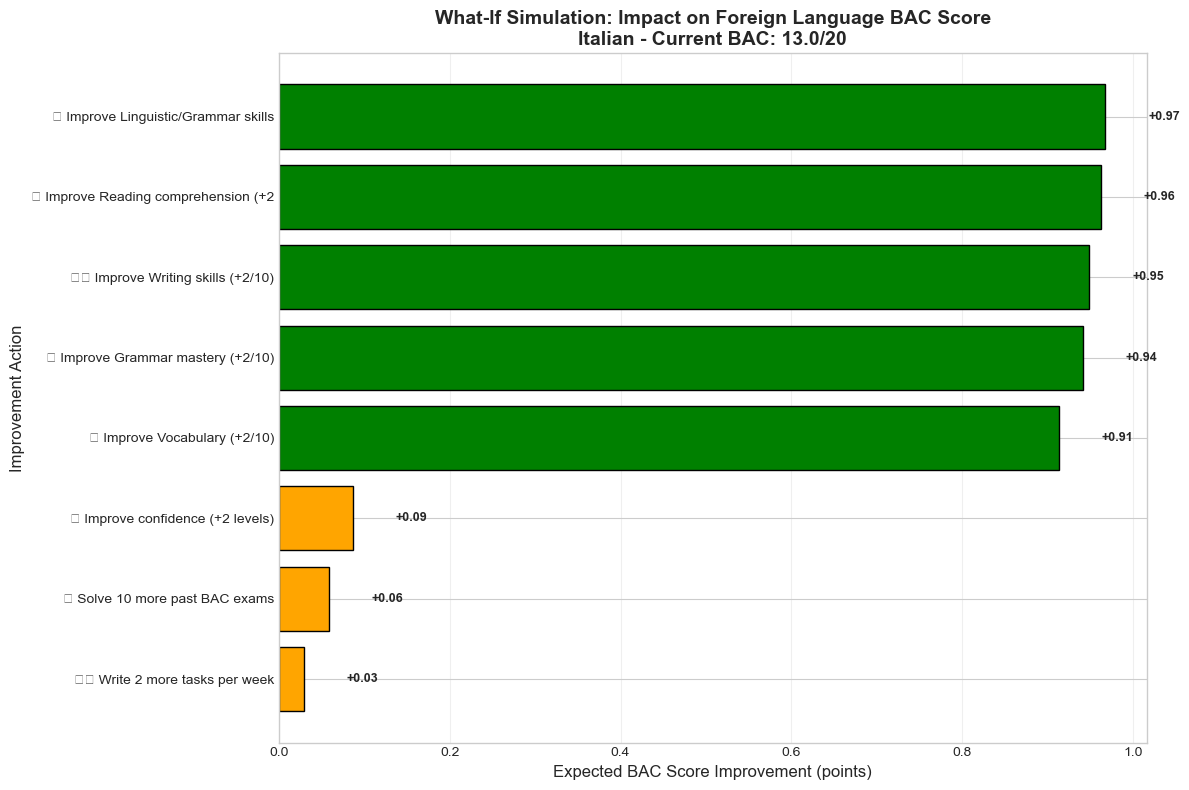


📊 IMPACT TABLE
                   Action Expected gain        Change
       Past exam practice  +0.01 points     +10 exams
    Reading comprehension  +0.48 points         +2/10
Linguistic/Grammar skills  +0.48 points         +2/10
           Writing skills  +0.47 points         +2/10
          Grammar mastery  +0.47 points         +2/10
               Vocabulary  +0.46 points         +2/10
        Writing frequency  +0.01 points +2 tasks/week
               Confidence  +0.04 points     +2 levels

✅ Simulation Engine Complete


In [19]:
# ============================================
# CELL 15: SIMULATION ENGINE (FOREIGN LANGUAGES)
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("⚡ SIMULATION ENGINE")
print("How improving your skills affects your BAC score")
print("=" * 60)

# ============================================
# Calculate real correlations from data
# ============================================

# Correlations with BAC score
bac_corr = df.corr()['bac_score']

# Extract key correlations (using available features)
reading_corr = bac_corr.get('reading_score', bac_corr.get('main_idea_detection', 0.75))
linguistic_corr = bac_corr.get('linguistic_score', bac_corr.get('grammar_transformation', 0.72))
writing_corr = bac_corr.get('writing_score', bac_corr.get('paragraph_structure', 0.68))
practice_corr = bac_corr.get('bac_subjects_practiced', 0.35)
grammar_corr = bac_corr.get('grammar_mastery', bac_corr.get('tense_mastery', 0.70))
vocab_corr = bac_corr.get('vocabulary_score', bac_corr.get('synonym_antonym', 0.65))
confidence_corr = bac_corr.get('confidence', 0.12)

print(f"\n📊 Real correlations from your data:")
print(f"   Reading score:     {reading_corr:.3f}")
print(f"   Linguistic score:  {linguistic_corr:.3f}")
print(f"   Writing score:     {writing_corr:.3f}")
print(f"   Practice:          {practice_corr:.3f}")
print(f"   Grammar mastery:   {grammar_corr:.3f}")
print(f"   Vocabulary:        {vocab_corr:.3f}")
print(f"   Confidence:        {confidence_corr:.3f}")

# ============================================
# Find a representative student
# ============================================

# Student with average BAC score
avg_bac = df['bac_score'].mean()
target_student = df.iloc[(df['bac_score'] - avg_bac).abs().argsort()[:1]].iloc[0]

# Get student's language
student_lang = {0: 'Spanish', 1: 'German', 2: 'Italian'}[target_student['language']]

print(f"\n👤 Selected student (average profile) - {student_lang}:")
print(f"   Current BAC score: {target_student['bac_score']:.1f}/20")
print(f"   Reading score: {target_student.get('reading_score', target_student.get('main_idea_detection', 6.5)):.1f}/10")
print(f"   Linguistic score: {target_student.get('linguistic_score', target_student.get('grammar_transformation', 6.5)):.1f}/10")
print(f"   Writing score: {target_student.get('writing_score', target_student.get('paragraph_structure', 6.5)):.1f}/10")
print(f"   Past exams solved: {target_student.get('bac_subjects_practiced', 5):.0f}")
print(f"   Writing tasks/week: {target_student.get('writing_tasks_per_week', 2):.0f}")

# ============================================
# Simulation function
# ============================================

def simulate_improvement_foreign(student, improvements):
    """
    Simulate how BAC score changes when student improves specific skills
    Based on real correlations from the data
    """
    original_score = student['bac_score']
    gain = 0
    
    # Impact factors (based on correlations)
    impact_factors = {
        'reading_score': reading_corr / 2,
        'linguistic_score': linguistic_corr / 2,
        'writing_score': writing_corr / 2,
        'bac_subjects_practiced': practice_corr / 10,
        'grammar_mastery': grammar_corr / 2,
        'vocabulary_score': vocab_corr / 2,
        'writing_tasks_per_week': practice_corr / 4,
        'confidence': confidence_corr / 2
    }
    
    for feature, delta in improvements.items():
        if feature in impact_factors:
            gain += delta * impact_factors[feature]
    
    new_score = min(original_score + gain, 20)
    new_score = max(new_score, 0)
    
    return {
        'original_score': original_score,
        'new_score': new_score,
        'gain': gain,
        'improvements': improvements
    }

# ============================================
# Test different scenarios
# ============================================

scenarios = [
    {"name": "📚 Solve 10 more past BAC exams", "changes": {"bac_subjects_practiced": 10}},
    {"name": "📖 Improve Reading comprehension (+2/10)", "changes": {"reading_score": 2}},
    {"name": "📚 Improve Linguistic/Grammar skills (+2/10)", "changes": {"linguistic_score": 2}},
    {"name": "✍️ Improve Writing skills (+2/10)", "changes": {"writing_score": 2}},
    {"name": "📖 Improve Grammar mastery (+2/10)", "changes": {"grammar_mastery": 2}},
    {"name": "📚 Improve Vocabulary (+2/10)", "changes": {"vocabulary_score": 2}},
    {"name": "✍️ Write 2 more tasks per week", "changes": {"writing_tasks_per_week": 2}},
    {"name": "💪 Improve confidence (+2 levels)", "changes": {"confidence": 2}},
    {"name": "✨ All improvements combined", "changes": {
        "bac_subjects_practiced": 10,
        "reading_score": 2,
        "linguistic_score": 2,
        "writing_score": 2,
        "grammar_mastery": 2,
        "vocabulary_score": 2,
        "writing_tasks_per_week": 2,
        "confidence": 2
    }}
]

print(f"\n📈 SIMULATION RESULTS:")
print("-" * 60)

results = []
for scenario in scenarios:
    result = simulate_improvement_foreign(target_student, scenario["changes"])
    results.append(result)
    
    # Color code based on gain
    if result['gain'] > 0.8:
        symbol = "🟢"
    elif result['gain'] > 0.4:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {scenario['name']}:")
    print(f"   {result['original_score']:.1f} → {result['new_score']:.1f}")
    print(f"   📈 Gain: +{result['gain']:.2f} points")

# ============================================
# Best action recommendation
# ============================================
print("\n" + "=" * 60)
print("🎯 BEST ACTION FOR THIS STUDENT")
print("=" * 60)

# Find best single action (excluding combined)
best_gain = -999
best_action = None
for i, scenario in enumerate(scenarios[:-1]):  # Exclude combined
    if results[i]['gain'] > best_gain:
        best_gain = results[i]['gain']
        best_action = scenario['name']

print(f"\n✅ Recommended: {best_action}")
print(f"   Expected improvement: +{best_gain:.2f} points")

# ============================================
# Visualization
# ============================================
fig, ax = plt.subplots(figsize=(12, 8))

# Show top 8 most impactful actions
top_indices = np.argsort([r['gain'] for r in results[:-1]])[-8:]  # Top 8 excluding combined
top_scenarios = [scenarios[i] for i in top_indices]
top_results = [results[i] for i in top_indices]

scenario_names = [s["name"][:35] for s in top_scenarios]
gains = [r['gain'] for r in top_results]

colors = ['green' if g > 0.6 else 'blue' if g > 0.3 else 'orange' if g > 0 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected BAC Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on Foreign Language BAC Score\n{student_lang} - Current BAC: {target_student["bac_score"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# Summary table
# ============================================
print("\n" + "=" * 60)
print("📊 IMPACT TABLE")
print("=" * 60)

impact_data = []
actions = [
    ('Past exam practice', practice_corr / 10, '+10 exams'),
    ('Reading comprehension', reading_corr / 2, '+2/10'),
    ('Linguistic/Grammar skills', linguistic_corr / 2, '+2/10'),
    ('Writing skills', writing_corr / 2, '+2/10'),
    ('Grammar mastery', grammar_corr / 2, '+2/10'),
    ('Vocabulary', vocab_corr / 2, '+2/10'),
    ('Writing frequency', practice_corr / 4, '+2 tasks/week'),
    ('Confidence', confidence_corr / 2, '+2 levels')
]

for action_name, impact_value, change_desc in actions:
    impact_data.append({
        'Action': action_name,
        'Expected gain': f"+{impact_value:.2f} points",
        'Change': change_desc
    })

impact_df = pd.DataFrame(impact_data)
print(impact_df.to_string(index=False))

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [9]:
# ============================================
# CELL 16: EXPLANATION OF DERIVED FEATURES (FOREIGN LANGUAGES)
# Student-friendly explanations for Spanish/German/Italian
# ============================================

from IPython.display import display, HTML
import numpy as np
import pandas as pd

print("=" * 60)
print("📖 UNDERSTANDING YOUR DERIVED SCORES")
print("What these numbers mean for your Foreign Language BAC")
print("Languages: Spanish | German | Italian")
print("=" * 60)

# ============================================
# Take a sample student (average profile)
# ============================================

# Find a student with average BAC score
avg_bac = df['bac_score'].mean()
sample_student = df.iloc[(df['bac_score'] - avg_bac).abs().argsort()[:1]].iloc[0]

# Get student's language
student_lang = {0: 'Spanish', 1: 'German', 2: 'Italian'}[sample_student['language']]

print(f"\n👤 Example Student ({student_lang}) - BAC score: {sample_student['bac_score']:.1f}/20")
print("-" * 60)

# ============================================
# Explain each derived feature
# ============================================

print("\n" + "=" * 60)
print("📊 1. READING SCORE")
print("=" * 60)

reading_val = sample_student.get('reading_score', sample_student.get('main_idea_detection', 6.5))
print(f"   Your score: {reading_val:.1f}/10")
print(f"   🤔 What does this mean?")
print(f"      This is your ability to understand texts in the target language.")
print(f"      It includes: finding main ideas, extracting details, true/false questions, and making inferences.")
if reading_val >= 7:
    print("   ✅ Excellent! You understand texts very well.")
elif reading_val >= 5:
    print("   📈 Good level! Practice more with different types of texts.")
else:
    print("   ⚠️ Needs improvement! Read short texts daily and practice comprehension questions.")
print(f"   💡 Tip: Read one short article in your target language every day.")

print("\n" + "=" * 60)
print("📚 2. LINGUISTIC SCORE")
print("=" * 60)

linguistic_val = sample_student.get('linguistic_score', sample_student.get('grammar_transformation', 6.5))
print(f"   Your score: {linguistic_val:.1f}/10")
print(f"   🤔 What does this mean?")
print(f"      This measures your knowledge of grammar and vocabulary.")
print(f"      It includes: synonyms/antonyms, word formation, tenses, sentence transformations, and prepositions.")
if linguistic_val >= 7:
    print("   ✅ Very good! Your grammar foundation is strong.")
elif linguistic_val >= 5:
    print("   📈 Good! Review grammar rules and practice regularly.")
else:
    print("   ⚠️ Needs work! Focus on basic tenses and common vocabulary first.")
print(f"   💡 Tip: Do 15 minutes of grammar exercises every day.")

print("\n" + "=" * 60)
print("✍️ 3. WRITING SCORE")
print("=" * 60)

writing_val = sample_student.get('writing_score', sample_student.get('paragraph_structure', 6.5))
print(f"   Your score: {writing_val:.1f}/10")
print(f"   🤔 What does this mean?")
print(f"      This is your ability to write paragraphs and essays in the target language.")
print(f"      It includes: paragraph structure, coherence, idea development, and language accuracy.")
if writing_val >= 7:
    print("   ✅ Great! Your writing is well-organized and clear.")
elif writing_val >= 5:
    print("   📈 Acceptable! Focus on structure and linking words.")
else:
    print("   ⚠️ Needs improvement! Practice writing one paragraph every day.")
print(f"   💡 Tip: Always write an introduction, body, and conclusion.")

print("\n" + "=" * 60)
print("⚡ 4. PRACTICE INTENSITY")
print("=" * 60)

practice_val = sample_student.get('practice_intensity', 5.0)
print(f"   Your score: {practice_val:.1f}/10")
print(f"   🤔 What does this mean?")
print(f"      This measures how much you practice through reading, exercises, and solving past exams.")
if practice_val >= 7:
    print("   ✅ Excellent practice habits! Keep it up.")
elif practice_val >= 5:
    print("   📈 Good practice! Increase your intensity slightly.")
else:
    print("   ⚠️ Low practice intensity! You need to practice more regularly.")
print(f"   💡 Tip: Solve one past BAC exam every week.")

print("\n" + "=" * 60)
print("🔤 5. GRAMMAR MASTERY")
print("=" * 60)

grammar_val = sample_student.get('grammar_mastery', sample_student.get('tense_mastery', 6.5))
print(f"   Your score: {grammar_val:.1f}/10")
print(f"   🤔 What does this mean?")
print(f"      This focuses specifically on tenses, grammar transformations, and sentence rewriting.")
if grammar_val >= 7:
    print("   ✅ Strong grammar skills!")
elif grammar_val >= 5:
    print("   📈 Good foundation! Review advanced grammar rules.")
else:
    print("   ⚠️ Grammar needs attention! Start with basic tenses.")
print(f"   💡 Tip: Practice transforming sentences from active to passive voice.")

print("\n" + "=" * 60)
print("📖 6. VOCABULARY SCORE")
print("=" * 60)

vocab_val = sample_student.get('vocabulary_score', sample_student.get('synonym_antonym', 6.5))
print(f"   Your score: {vocab_val:.1f}/10")
print(f"   🤔 What does this mean?")
print(f"      This measures your knowledge of synonyms, antonyms, and word families.")
if vocab_val >= 7:
    print("   ✅ Rich vocabulary! This helps a lot in reading and writing.")
elif vocab_val >= 5:
    print("   📈 Good vocabulary! Learn 5-10 new words per week.")
else:
    print("   ⚠️ Limited vocabulary! Read more to encounter new words.")
print(f"   💡 Tip: Keep a vocabulary notebook and review it weekly.")

print("\n" + "=" * 60)
print("📊 7. OVERALL PROFICIENCY")
print("=" * 60)

overall_val = sample_student.get('overall_proficiency', 6.5)
print(f"   Your score: {overall_val:.1f}/10")
print(f"   🤔 What does this mean?")
print(f"      This is your average score across reading, grammar, and writing.")
if overall_val >= 7:
    print("   ✅ You are on track for a very good BAC score!")
elif overall_val >= 5:
    print("   📈 You have a solid foundation. Keep working on all skills.")
else:
    print("   ⚠️ You need to invest more time in language practice.")
print(f"   💡 Tip: Consistency is key. Study a little every day.")

print("\n" + "=" * 60)
print("⚖️ 8. SKILL BALANCE")
print("=" * 60)

imbalance_val = sample_student.get('imbalance_score', 1.0)
print(f"   Your score: {imbalance_val:.2f}")
print(f"   🤔 What does this mean?")
print(f"      This measures how balanced your reading, grammar, and writing skills are.")
if imbalance_val < 0.5:
    print("   ✅ Excellent! Your skills are very well balanced.")
elif imbalance_val < 1.0:
    print("   📈 Good balance! Small differences between skills.")
else:
    print("   ⚠️ Imbalance detected! Some skills are much stronger than others.")
print(f"   💡 Tip: Focus on your weakest skill to create better balance.")

print("\n" + "=" * 60)
print("📈 9. GRADE TREND")
print("=" * 60)

trend_val = sample_student.get('grade_trend', 0)
print(f"   Your trend: {trend_val:+.1f} points")
print(f"   🤔 What does this mean?")
print(f"      This shows how your grades have evolved from trimester 1 to trimester 3.")
if trend_val > 1:
    print("   ✅ Excellent progress! You are improving significantly.")
elif trend_val > 0:
    print("   📈 Positive trend! Keep working hard.")
elif trend_val == 0:
    print("   📊 Stable! Try to push yourself a bit more.")
else:
    print("   ⚠️ Declining trend! Identify what changed and address it.")
print(f"   💡 Tip: Consistency in study habits leads to positive trends.")

print("\n" + "=" * 60)
print("🧠 10. PSYCHOLOGICAL BALANCE")
print("=" * 60)

psycho_val = sample_student.get('psycho_balance', 0)
print(f"   Your balance: {psycho_val:+.1f}")
print(f"   🤔 What does this mean?")
print(f"      This is the difference between your confidence and stress levels.")
if psycho_val > 0:
    print("   ✅ Good balance! Your confidence helps you perform better.")
elif psycho_val == 0:
    print("   📊 Neutral balance. Work on building more confidence.")
else:
    print("   ⚠️ Stress is affecting you. Practice relaxation techniques.")
print(f"   💡 Tip: Believe in yourself and prepare well to reduce stress.")

print("\n" + "=" * 60)
print("💡 TIPS FOR EACH LANGUAGE")
print("=" * 60)

print("\n🇪🇸 SPANISH:")
print("   • Focus on verb conjugations (present, past, future)")
print("   • Practice the subjunctive mood")
print("   • Learn common idioms and expressions")

print("\n🇩🇪 GERMAN:")
print("   • Master the cases (Nominativ, Akkusativ, Dativ, Genitiv)")
print("   • Practice separable verbs and word order")
print("   • Learn noun genders (der, die, das)")

print("\n🇮🇹 ITALIAN:")
print("   • Focus on verb conjugations (are, ere, ire)")
print("   • Practice the passato prossimo and imperfetto")
print("   • Learn common prepositions and articles")

print("\n" + "=" * 60)
print("✅ Understanding these scores helps you focus on what matters most")
print("=" * 60)

📖 UNDERSTANDING YOUR DERIVED SCORES
What these numbers mean for your Foreign Language BAC
Languages: Spanish | German | Italian

👤 Example Student (Italian) - BAC score: 13.0/20
------------------------------------------------------------

📊 1. READING SCORE
   Your score: 6.5/10
   🤔 What does this mean?
      This is your ability to understand texts in the target language.
      It includes: finding main ideas, extracting details, true/false questions, and making inferences.
   📈 Good level! Practice more with different types of texts.
   💡 Tip: Read one short article in your target language every day.

📚 2. LINGUISTIC SCORE
   Your score: 6.0/10
   🤔 What does this mean?
      This measures your knowledge of grammar and vocabulary.
      It includes: synonyms/antonyms, word formation, tenses, sentence transformations, and prepositions.
   📈 Good! Review grammar rules and practice regularly.
   💡 Tip: Do 15 minutes of grammar exercises every day.

✍️ 3. WRITING SCORE
   Your score: 5

In [21]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (FOREIGN LANGUAGES)
# Spanish | German | Italian
# ============================================

from IPython.display import display, HTML, Markdown

print("=" * 80)
print("📚 FOREIGN LANGUAGES BAC IMPROVEMENT PLATFORM")
print("Spanish | German | Italian")
print("=" * 80)

# Professional HTML layout
intro_html = """
<div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">📖 Foreign Languages Baccalaureate Exam</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">
            Spanish | German | Italian
        </p>
        <p style="margin: 5px 0 0 0; font-size: 14px; opacity: 0.8;">
            Stream: Foreign Languages
        </p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-left: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">Duration</div>
            <div style="font-size: 14px;">3 hours</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-left: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">Total Points</div>
            <div style="font-size: 14px;">20 points</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-left: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">Two Topics</div>
            <div style="font-size: 14px;">Choose one topic</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 Exam Structure (All Languages)</h2>
    </div>
"""

# Exam structure table
structure_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">📖 Foreign Language BAC - All Languages</h3>
        <table style="width: 100%; border-collapse: collapse;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">Section</th>
                <th style="padding: 10px; text-align: center;">Points</th>
                <th style="padding: 10px; text-align: center;">Weight</th>
                <th style="padding: 10px; text-align: center;">Skills Tested</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>Reading Comprehension</strong><br>(Comprensión / Textverständnis / Comprensione)</td>
                <td style="padding: 10px; text-align: center;">7-8 points</td>
                <td style="padding: 10px; text-align: center;">35-40%</td>
                <td style="padding: 10px;">Main idea, details, true/false, references, inference</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>Linguistic Competence</strong><br>(Lengua / Sprachfähigkeit / Competenza linguistica)</td>
                <td style="padding: 10px; text-align: center;">7-8 points</td>
                <td style="padding: 10px; text-align: center;">35-40%</td>
                <td style="padding: 10px;">Vocabulary, grammar, tenses, transformations, prepositions, translation</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>Written Production</strong><br>(Producción / Schreibfähigkeit / Produzione scritta)</td>
                <td style="padding: 10px; text-align: center;">5-6 points</td>
                <td style="padding: 10px; text-align: center;">25-30%</td>
                <td style="padding: 10px;">Essay writing, paragraph structure, coherence, language accuracy</td>
             </tr>
        </table>
    </div>
"""

# Language-specific details
language_details = """
    <div style="display: flex; gap: 20px; margin-bottom: 20px; flex-wrap: wrap;">
        <div style="flex: 1; background: #f0f8ff; padding: 15px; border-radius: 10px; border-left: 4px solid #e74c3c;">
            <h3 style="color: #c0392b; margin-top: 0;">🇪🇸 Spanish</h3>
            <ul style="margin: 0; padding-left: 20px;">
                <li>Verb conjugations (present, preterite, imperfect, future, subjunctive)</li>
                <li>Ser vs Estar</li>
                <li>Por vs Para</li>
                <li>Direct/indirect object pronouns</li>
            </ul>
        </div>
        <div style="flex: 1; background: #f0f8ff; padding: 15px; border-radius: 10px; border-left: 4px solid #f39c12;">
            <h3 style="color: #e67e22; margin-top: 0;">🇩🇪 German</h3>
            <ul style="margin: 0; padding-left: 20px;">
                <li>Cases (Nominativ, Akkusativ, Dativ, Genitiv)</li>
                <li>Separable verbs</li>
                <li>Word order (verb second, verb last)</li>
                <li>Modal verbs (können, müssen, wollen, dürfen)</li>
            </ul>
        </div>
        <div style="flex: 1; background: #f0f8ff; padding: 15px; border-radius: 10px; border-left: 4px solid #2ecc71;">
            <h3 style="color: #27ae60; margin-top: 0;">🇮🇹 Italian</h3>
            <ul style="margin: 0; padding-left: 20px;">
                <li>Verb conjugations (are, ere, ire)</li>
                <li>Passato prossimo vs imperfetto</li>
                <li>Subjunctive (congiuntivo)</li>
                <li>Prepositions and articles</li>
            </ul>
        </div>
    </div>
"""

# Importance ranking
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">⭐ What Matters Most?</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>Grammar & Transformations</strong></div>
                <div style="font-size: 12px; color: #666;">Most important (40%)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>Reading Comprehension</strong></div>
                <div style="font-size: 12px; color: #666;">Very important (35%)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>Writing Production</strong></div>
                <div style="font-size: 12px; color: #666;">Important (25%)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>Past Exam Practice</strong></div>
                <div style="font-size: 12px; color: #666;">Boosts your score</div>
            </div>
        </div>
    </div>
"""

# How the platform works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 How This Platform Works</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>Enter your information</strong> - Fill out the form with your grades and skill levels</li>
            <li>🔮 <strong>Get your predicted score</strong> - Calculate your estimated BAC score</li>
            <li>📊 <strong>Analyze strengths & weaknesses</strong> - Identify what you need to improve</li>
            <li>⚡ <strong>Simulate improvements</strong> - Test different scenarios to see how your score changes</li>
            <li>🎯 <strong>Receive personalized recommendations</strong> - Get specific advice to boost your score</li>
        </ul>
    </div>
"""

# Key advice
advice_html = """
    <div style="background: #fef9e7; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #f39c12;">
        <h3 style="color: #7d6608; margin-top: 0;">💪 Key to Success</h3>
        <p style="line-height: 1.6;">
            The most effective way to improve your Foreign Language BAC score is <strong>regular practice with past exams</strong>.
            Solving past papers helps you recognize patterns, understand question types, and build confidence.
        </p>
        <p style="line-height: 1.6; margin-top: 10px;">
            📌 <strong>Daily habits that work:</strong> Study grammar for 15 minutes, learn 10 new words, read one short text, and write 5 sentences.
        </p>
    </div>
"""

# Language selection tip
lang_tip = """
    <div style="background: #e8f0ff; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #9b59b6;">
        <h3 style="color: #8e44ad; margin-top: 0;">🌍 Choose Your Language</h3>
        <p style="margin: 0;">
            This platform works for <strong>Spanish, German, and Italian</strong>. 
            Select your language when entering your data. The platform will adapt the recommendations to your specific language!
        </p>
    </div>
"""

# Combine all
full_html = intro_html + structure_html + language_details + importance_html + lang_tip + how_it_works + advice_html + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555;">✨ This platform is based on real BAC exam data analysis for Spanish, German, and Italian ✨</p>
        <p style="color: #888; font-size: 12px;">Developed to help students improve their Foreign Language Baccalaureate performance</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ Ready for the next step: Enter your data in Cell 17b")
print("=" * 80)

📚 FOREIGN LANGUAGES BAC IMPROVEMENT PLATFORM
Spanish | German | Italian


Section,Points,Weight,Skills Tested
Reading Comprehension(Comprensión / Textverständnis / Comprensione),7-8 points,35-40%,"Main idea, details, true/false, references, inference"
Linguistic Competence(Lengua / Sprachfähigkeit / Competenza linguistica),7-8 points,35-40%,"Vocabulary, grammar, tenses, transformations, prepositions, translation"
Written Production(Producción / Schreibfähigkeit / Produzione scritta),5-6 points,25-30%,"Essay writing, paragraph structure, coherence, language accuracy"



✅ Ready for the next step: Enter your data in Cell 17b


In [22]:
# ============================================
# CELL 17b: USER INPUT FORM (FOREIGN LANGUAGES)
# Spanish | German | Italian
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 STUDENT DATA ENTRY - FOREIGN LANGUAGES")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 Enter Your Academic Information</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">All information is confidential and used only for prediction</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Stream (Filiere) - Fixed for Foreign Languages
# ============================================

stream_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 4px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">🎓 Your Stream</h3>
    <p style="color: #666;">You are in the Foreign Languages stream (Spanish / German / Italian)</p>
</div>
"""
display(HTML(stream_html))

# Fixed filiere value for Foreign Languages
filiere = 1  # Foreign Languages stream

# ============================================
# SECTION 2: Language Selection
# ============================================

lang_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🌍 1. Select Your Language</h3>
</div>
"""
display(HTML(lang_html))

language_dropdown = widgets.Dropdown(
    options=[
        ('Spanish (Español)', 0),
        ('German (Deutsch)', 1),
        ('Italian (Italiano)', 2)
    ],
    value=0,
    description='',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='100%', padding='10px')
)
display(language_dropdown)

# ============================================
# SECTION 3: Trimester Grades
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 2. Your Trimester Grades</h3>
    <p style="color: #666; font-size: 14px;">Enter your foreign language grades (0 to 20)</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_t1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='Trimester 1:', 
                               style={'description_width': '100px'}, layout=grade_style)
grade_t2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='Trimester 2:', 
                               style={'description_width': '100px'}, layout=grade_style)
grade_t3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='Trimester 3:', 
                               style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_t1, grade_t2, grade_t3], layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 4: Reading Comprehension Skills
# ============================================

reading_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📖 3. Reading Comprehension Skills</h3>
    <p style="color: #666; font-size: 14px;">Rate yourself from 0 to 10 (0 = weak, 10 = excellent)</p>
</div>
"""
display(HTML(reading_html))

skill_style = widgets.Layout(width='100%', padding='5px')

# Reading skills
main_idea = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 Main idea detection:', 
                                style={'description_width': '220px'}, layout=skill_style)
detail_extraction = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔍 Detail extraction:', 
                                        style={'description_width': '220px'}, layout=skill_style)
true_false = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='✓✗ True/False accuracy:', 
                                 style={'description_width': '220px'}, layout=skill_style)
reference = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔗 Reference resolution (pronouns):', 
                                style={'description_width': '220px'}, layout=skill_style)
inference = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🎯 Inference skill:', 
                                style={'description_width': '220px'}, layout=skill_style)

reading_grid = widgets.GridBox([main_idea, detail_extraction, true_false, reference, inference],
                               layout=widgets.Layout(grid_template_columns='1fr 1fr', grid_gap='10px'))
display(reading_grid)

# ============================================
# SECTION 5: Linguistic Competence Skills
# ============================================

linguistic_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 4. Linguistic Competence (Grammar & Vocabulary)</h3>
    <p style="color: #666; font-size: 14px;">Rate yourself from 0 to 10</p>
</div>
"""
display(HTML(linguistic_html))

synonym = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 Synonyms & Antonyms:', 
                              style={'description_width': '220px'}, layout=skill_style)
word_formation = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔤 Word formation (prefix/suffix):', 
                                     style={'description_width': '220px'}, layout=skill_style)
tense = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='⏰ Tense mastery (past/present/future):', 
                            style={'description_width': '220px'}, layout=skill_style)
grammar_trans = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='✍️ Grammar transformation:', 
                                    style={'description_width': '220px'}, layout=skill_style)
sentence_rewrite = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📝 Sentence rewriting:', 
                                       style={'description_width': '220px'}, layout=skill_style)
preposition = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📍 Preposition mastery:', 
                                  style={'description_width': '220px'}, layout=skill_style)
translation = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🌐 Translation skill:', 
                                  style={'description_width': '220px'}, layout=skill_style)

linguistic_grid = widgets.GridBox([synonym, word_formation, tense, grammar_trans, sentence_rewrite, preposition, translation],
                                  layout=widgets.Layout(grid_template_columns='1fr 1fr', grid_gap='10px'))
display(linguistic_grid)

# ============================================
# SECTION 6: Writing Skills
# ============================================

writing_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">✍️ 5. Writing Skills</h3>
    <p style="color: #666; font-size: 14px;">Rate yourself from 0 to 10</p>
</div>
"""
display(HTML(writing_html))

paragraph = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📋 Paragraph structure:', 
                                style={'description_width': '220px'}, layout=skill_style)
coherence = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔗 Coherence (logical flow):', 
                                style={'description_width': '220px'}, layout=skill_style)
idea_dev = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='💡 Idea development:', 
                               style={'description_width': '220px'}, layout=skill_style)
lang_accuracy = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 Language accuracy:', 
                                    style={'description_width': '220px'}, layout=skill_style)

writing_grid = widgets.GridBox([paragraph, coherence, idea_dev, lang_accuracy],
                               layout=widgets.Layout(grid_template_columns='1fr 1fr', grid_gap='10px'))
display(writing_grid)

# ============================================
# SECTION 7: Practice & Study Habits
# ============================================

practice_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #1abc9c;">
    <h3 style="color: #2c3e50; margin-top: 0;">⏰ 6. Practice & Study Habits</h3>
</div>
"""
display(HTML(practice_html))

texts_read = widgets.IntSlider(value=5, min=0, max=10, step=1, 
                               description='📖 Texts read per week:', 
                               style={'description_width': '220px'}, layout=skill_style)
exercises = widgets.IntSlider(value=5, min=0, max=20, step=1, 
                              description='📝 Grammar exercises per week:', 
                              style={'description_width': '220px'}, layout=skill_style)
past_exams = widgets.IntSlider(value=5, min=0, max=20, step=1, 
                               description='📚 Past BAC exams solved:', 
                               style={'description_width': '220px'}, layout=skill_style)
writing_tasks = widgets.IntSlider(value=2, min=0, max=5, step=1, 
                                  description='✍️ Writing tasks per week:', 
                                  style={'description_width': '220px'}, layout=skill_style)

display(texts_read, exercises, past_exams, writing_tasks)

# ============================================
# SECTION 8: Psychological Factors
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 7. Psychological Factors</h3>
</div>
"""
display(HTML(psycho_html))

confidence = widgets.RadioButtons(
    options=[('Very Low', 1), ('Low', 2), ('Medium', 3), ('High', 4), ('Very High', 5)],
    value=3,
    description='💪 Confidence:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

stress = widgets.RadioButtons(
    options=[('Very High', 5), ('High', 4), ('Medium', 3), ('Low', 2), ('Very Low', 1)],
    value=3,
    description='😰 Stress level:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

display(confidence, stress)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 Ready to predict your BAC score?")
print("=" * 80)

submit_button = widgets.Button(
    description='🔮 Predict My BAC Score',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)

submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect all inputs
def collect_inputs(b):
    clear_output(wait=True)
    
    # Re-display the form
    display(HTML(form_header))
    display(stream_html)
    display(lang_html)
    display(language_dropdown)
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(reading_html))
    display(reading_grid)
    display(HTML(linguistic_html))
    display(linguistic_grid)
    display(HTML(writing_html))
    display(writing_grid)
    display(HTML(practice_html))
    display(texts_read, exercises, past_exams, writing_tasks)
    display(HTML(psycho_html))
    display(confidence, stress)
    display(submit_button)
    
    # Collect all values
    student_data = {
        'filiere': 1,  # Foreign Languages stream
        'language': language_dropdown.value,
        'grade_t1': grade_t1.value,
        'grade_t2': grade_t2.value,
        'grade_t3': grade_t3.value,
        # Reading skills
        'main_idea_detection': main_idea.value,
        'detail_extraction': detail_extraction.value,
        'true_false_accuracy': true_false.value,
        'reference_resolution': reference.value,
        'inference_skill': inference.value,
        # Linguistic skills
        'synonym_antonym': synonym.value,
        'word_formation': word_formation.value,
        'tense_mastery': tense.value,
        'grammar_transformation': grammar_trans.value,
        'sentence_rewriting': sentence_rewrite.value,
        'preposition_mastery': preposition.value,
        'translation_skill': translation.value,
        # Writing skills
        'paragraph_structure': paragraph.value,
        'coherence_cohesion': coherence.value,
        'idea_development': idea_dev.value,
        'language_accuracy': lang_accuracy.value,
        # Practice habits
        'texts_read_per_week': texts_read.value,
        'exercises_done_per_week': exercises.value,
        'bac_subjects_practiced': past_exams.value,
        'writing_tasks_per_week': writing_tasks.value,
        # Psychological
        'confidence': confidence.value,
        'stress': stress.value
    }
    
    # Store in global variable
    global user_input
    user_input = student_data
    
    lang_name = {0: 'Spanish', 1: 'German', 2: 'Italian'}[language_dropdown.value]
    
    print("\n" + "=" * 80)
    print("✅ Your data has been recorded successfully!")
    print("=" * 80)
    print("\n📊 Summary of your input:")
    print(f"   Language: {lang_name}")
    print(f"   Grades: T1={grade_t1.value:.1f}, T2={grade_t2.value:.1f}, T3={grade_t3.value:.1f}")
    print(f"   Reading comprehension: {main_idea.value:.1f}/10")
    print(f"   Grammar & vocabulary: {synonym.value:.1f}/10")
    print(f"   Writing skills: {paragraph.value:.1f}/10")
    print(f"   Past exams solved: {past_exams.value}")
    print("\n🔮 Proceed to Cell 17c for your prediction!")

submit_button.on_click(collect_inputs)
display(submit_button)

print("\n💡 Tip: Be honest in your self-assessment for an accurate prediction")

📝 STUDENT DATA ENTRY - FOREIGN LANGUAGES


Dropdown(layout=Layout(padding='10px', width='100%'), options=(('Spanish (Español)', 0), ('German (Deutsch)', …

GridBox(children=(FloatSlider(value=6.0, description='📖 Main idea detection:', layout=Layout(padding='5px', wi…

GridBox(children=(FloatSlider(value=6.0, description='📖 Synonyms & Antonyms:', layout=Layout(padding='5px', wi…

GridBox(children=(FloatSlider(value=6.0, description='📋 Paragraph structure:', layout=Layout(padding='5px', wi…

...

RadioButtons(description='💪 Confidence:', index=2, layout=Layout(padding='5px', width='100%'), options=(('Very…

RadioButtons(description='😰 Stress level:', index=2, layout=Layout(padding='5px', width='100%'), options=(('Ve…


🚀 Ready to predict your BAC score?


Button(button_style='success', description='🔮 Predict My BAC Score', icon='check', layout=Layout(margin='20px …


💡 Tip: Be honest in your self-assessment for an accurate prediction


In [23]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (FOREIGN LANGUAGES)
# Professional prediction display
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ Model has not been trained yet!")
    print("=" * 80)
    print("\n📌 Please run Cell 11 (Model Training) first")
    print("   Then come back to this cell")
    print("=" * 80)
elif 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate prediction
    # ============================================
    
    # Create DataFrame from user input
    input_df = pd.DataFrame([user_input])
    
    # Calculate derived features
    input_df['avg_grade'] = (input_df['grade_t1'] + input_df['grade_t2'] + input_df['grade_t3']) / 3
    
    # Reading score
    reading_cols = ['main_idea_detection', 'detail_extraction', 'true_false_accuracy', 
                    'reference_resolution', 'inference_skill']
    input_df['reading_score'] = input_df[reading_cols].mean(axis=1)
    
    # Linguistic score
    linguistic_cols = ['synonym_antonym', 'word_formation', 'tense_mastery', 
                       'grammar_transformation', 'sentence_rewriting', 
                       'preposition_mastery', 'translation_skill']
    input_df['linguistic_score'] = input_df[linguistic_cols].mean(axis=1)
    
    # Writing score
    writing_cols = ['paragraph_structure', 'coherence_cohesion', 'idea_development', 'language_accuracy']
    input_df['writing_score'] = input_df[writing_cols].mean(axis=1)
    
    # Practice intensity
    input_df['practice_intensity'] = (input_df['writing_tasks_per_week'] * 2 + 
                                       input_df['texts_read_per_week'] + 
                                       input_df['bac_subjects_practiced'] / 2 + 
                                       input_df['exercises_done_per_week'] / 2) / 4
    
    # Grammar mastery
    grammar_cols = ['tense_mastery', 'grammar_transformation', 'sentence_rewriting']
    input_df['grammar_mastery'] = input_df[grammar_cols].mean(axis=1)
    
    # Vocabulary score
    vocab_cols = ['synonym_antonym', 'word_formation']
    input_df['vocabulary_score'] = input_df[vocab_cols].mean(axis=1)
    
    # Overall proficiency
    input_df['overall_proficiency'] = (input_df['reading_score'] + 
                                        input_df['linguistic_score'] + 
                                        input_df['writing_score']) / 3
    
    # Grade trend and stability
    input_df['grade_trend'] = input_df['grade_t3'] - input_df['grade_t1']
    input_df['grade_stability'] = 0.7
    
    # Imbalance score
    skills_var = np.var([input_df['reading_score'].values[0], 
                         input_df['linguistic_score'].values[0], 
                         input_df['writing_score'].values[0]])
    input_df['imbalance_score'] = skills_var
    
    # Psycho balance
    input_df['psycho_balance'] = input_df['confidence'] - input_df['stress']
    
    # Study efficiency
    input_df['study_efficiency'] = 0.5
    
    # Get model features
    model_features = X_train.columns.tolist()
    
    # Add missing columns
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Select only model features
    X_input = input_df[model_features]
    
    # Make prediction
    prediction = model.predict(X_input)[0]
    predicted_score = prediction[0]
    success_prob = prediction[1] * 100
    improvement_potential = prediction[2]
    
    # Language name
    lang_names = {0: 'Spanish', 1: 'German', 2: 'Italian'}
    student_lang = lang_names[user_input['language']]
    
    # Determine color based on score
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "Excellent"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "Very Good"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "Good"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "Passable"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "Needs Improvement"
    
    # Success probability color
    if success_prob >= 80:
        prob_color = "#2ecc71"
    elif success_prob >= 60:
        prob_color = "#f39c12"
    else:
        prob_color = "#e74c3c"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    prediction_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 Your Predicted BAC Score</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Based on your personal data - {student_lang}</p>
        </div>
        
        <!-- Main Score Card -->
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">Your estimated BAC score</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} Level: {score_text} {score_emoji}
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Score Details -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-left: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 Score Details</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 Predicted score</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ Chance of success (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 Improvement potential</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} points</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <!-- Right Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 Your Information</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>🌍 Language</span>
                        <span style="font-weight: bold;">{student_lang}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 Average trimester grade</span>
                        <span style="font-weight: bold;">{((user_input['grade_t1'] + user_input['grade_t2'] + user_input['grade_t3'])/3):.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📚 Past exams solved</span>
                        <span style="font-weight: bold;">{user_input['bac_subjects_practiced']}</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Skills Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 Your Skills Summary</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    <div>📖 Reading: <strong>{input_df['reading_score'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['reading_score'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>📚 Grammar: <strong>{input_df['linguistic_score'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['linguistic_score'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>✍️ Writing: <strong>{input_df['writing_score'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['writing_score'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>🔤 Grammar Mastery: <strong>{input_df['grammar_mastery'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['grammar_mastery'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>📖 Vocabulary: <strong>{input_df['vocabulary_score'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['vocabulary_score'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>⚡ Practice: <strong>{input_df['practice_intensity'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['practice_intensity'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Key Advice -->
        <div style="background: #fef9e7; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-left: 4px solid #f39c12;">
            <p style="margin: 0; color: #7d6608;">
                💡 <strong>Key advice:</strong> Solving past BAC exams is one of the best ways to improve your score. 
                Each exam you solve helps you recognize patterns and build confidence!
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ Edit Your Data
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 Weakness Analysis →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ This prediction is based on your real data ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction for later cells
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ Proceed to Cell 17d for Weakness Analysis")
    print("=" * 80)


✅ Proceed to Cell 17d for Weakness Analysis


In [24]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (FOREIGN LANGUAGES)
# Professional analysis of student's strengths and weaknesses
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ Model has not been trained yet!")
    print("=" * 80)
    print("📌 Please run Cell 11 (Model Training) first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate weaknesses based on user input
    # ============================================
    
    # Target levels for each skill (based on BAC requirements)
    skill_targets = {
        # Reading skills
        'main_idea_detection': 7.5,
        'detail_extraction': 7.0,
        'true_false_accuracy': 7.0,
        'reference_resolution': 7.0,
        'inference_skill': 7.0,
        
        # Linguistic skills
        'synonym_antonym': 7.0,
        'word_formation': 7.0,
        'tense_mastery': 7.5,
        'grammar_transformation': 7.0,
        'sentence_rewriting': 7.0,
        'preposition_mastery': 7.0,
        'translation_skill': 7.0,
        
        # Writing skills
        'paragraph_structure': 7.5,
        'coherence_cohesion': 7.0,
        'idea_development': 7.0,
        'language_accuracy': 7.0
    }
    
    # Get user's skill values
    user_skills = {skill: user_input.get(skill, 6.0) for skill in skill_targets.keys()}
    
    # Calculate gaps
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    # Sort weaknesses
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths (skills above target)
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 7.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # ============================================
    # Study habits weaknesses
    # ============================================
    
    habit_targets = {
        'bac_subjects_practiced': 15,
        'writing_tasks_per_week': 3,
        'texts_read_per_week': 7,
        'exercises_done_per_week': 10,
        'confidence': 4
    }
    
    user_habits = {habit: user_input.get(habit, 5) for habit in habit_targets.keys()}
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        gap = target - user_habits[habit]
        if gap > 0:
            habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Stress level
    stress_level = user_input.get('stress', 3)
    stress_issue = stress_level >= 4
    
    # Language name
    lang_names = {0: 'Spanish', 1: 'German', 2: 'Italian'}
    student_lang = lang_names[user_input['language']]
    
    # ============================================
    # Skill names in English
    # ============================================
    
    skill_names_en = {
        # Reading
        'main_idea_detection': 'Main Idea Detection',
        'detail_extraction': 'Detail Extraction',
        'true_false_accuracy': 'True/False Accuracy',
        'reference_resolution': 'Reference Resolution (pronouns)',
        'inference_skill': 'Inference Skill',
        
        # Linguistic
        'synonym_antonym': 'Synonyms & Antonyms',
        'word_formation': 'Word Formation (prefixes/suffixes)',
        'tense_mastery': 'Tense Mastery',
        'grammar_transformation': 'Grammar Transformation',
        'sentence_rewriting': 'Sentence Rewriting',
        'preposition_mastery': 'Preposition Mastery',
        'translation_skill': 'Translation Skill',
        
        # Writing
        'paragraph_structure': 'Paragraph Structure',
        'coherence_cohesion': 'Coherence & Cohesion',
        'idea_development': 'Idea Development',
        'language_accuracy': 'Language Accuracy'
    }
    
    habit_names_en = {
        'bac_subjects_practiced': 'Past BAC Exams Solved',
        'writing_tasks_per_week': 'Writing Tasks per Week',
        'texts_read_per_week': 'Texts Read per Week',
        'exercises_done_per_week': 'Grammar Exercises per Week',
        'confidence': 'Confidence'
    }
    
    # Specific advice for each skill
    advice_map = {
        'main_idea_detection': 'Practice identifying the main idea of paragraphs in articles',
        'detail_extraction': 'Practice finding specific information in texts',
        'true_false_accuracy': 'Practice true/false questions with justification',
        'reference_resolution': 'Practice finding what pronouns (it/they/this) refer to',
        'inference_skill': 'Practice reading between the lines and making predictions',
        'synonym_antonym': 'Use a thesaurus and learn word families',
        'word_formation': 'Learn common prefixes (un-, re-, dis-) and suffixes (-ment, -tion)',
        'tense_mastery': 'Review past, present, and perfect tenses',
        'grammar_transformation': 'Practice transforming sentences (active/passive, direct/indirect)',
        'sentence_rewriting': 'Practice rewriting sentences in different structures',
        'preposition_mastery': 'Learn common preposition combinations',
        'translation_skill': 'Practice translating sentences daily',
        'paragraph_structure': 'Always use topic sentences and supporting details',
        'coherence_cohesion': 'Use linking words (however, therefore, moreover, consequently)',
        'idea_development': 'Develop ideas with examples and explanations',
        'language_accuracy': 'Review common grammar errors in your writing'
    }
    
    habit_advice = {
        'bac_subjects_practiced': 'Solve one complete BAC exam every week',
        'writing_tasks_per_week': 'Write at least one paragraph or essay per week',
        'texts_read_per_week': 'Read for 15-20 minutes daily in your target language',
        'exercises_done_per_week': 'Do 10-15 minutes of grammar exercises daily',
        'confidence': 'Start with easier exercises to build confidence'
    }
    
    # ============================================
    # Calculate overall weakness score
    # ============================================
    
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 50
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    weakness_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 Weakness & Strength Analysis</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">{student_lang} - Understand your skills to improve effectively</p>
        </div>
        
        <!-- Weakness Score Card -->
        <div style="background: linear-gradient(135deg, {('#e74c3c' if weakness_score > 60 else '#f39c12' if weakness_score > 30 else '#2ecc71')} 0%, {('#c0392b' if weakness_score > 60 else '#e67e22' if weakness_score > 30 else '#27ae60')} 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">Overall Improvement Needed</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ Multiple areas need improvement' if weakness_score > 60 else '📈 Good progress possible' if weakness_score > 30 else '✅ Good overall level'}
            </p>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Weaknesses -->
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-left: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 Areas to Improve (Priority)</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add top 5 skill weaknesses
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:5]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            skill_name = skill_names_en.get(skill, skill)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">📖 {skill_name}</span>
                            <span>{current:.1f}/10 → Target: {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice_map.get(skill, 'Practice this skill regularly')}
                        </p>
                    </div>
            """
    
    # Add top 2 habit weaknesses
    for habit, gap in sorted_habits[:2]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        habit_name = habit_names_en.get(habit, habit)
        weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">⏰ {habit_name}</span>
                            <span>{current:.0f} → Target: {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {habit_advice.get(habit, 'Develop a consistent study routine')}
                        </p>
                    </div>
        """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 Great job! No major weaknesses identified!</p>
                        <p style="color: #666;">Keep up the good work and maintain your level</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <!-- Right Column: Strengths -->
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-left: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 Your Strengths</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add top 5 strengths
    if len(strengths) > 0:
        for skill, excess in strengths[:5]:
            skill_name = skill_names_en.get(skill, skill)
            current = user_skills[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">📖 {skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            ✅ Keep maintaining this skill
                        </p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 Work on building your core skills</p>
                        <p style="color: #666;">Regular practice will help you develop strengths</p>
                    </div>
        """
    
    # Stress warning
    if stress_issue:
        weakness_html += f"""
                    <div style="margin-top: 20px; padding: 15px; background: #fff3cd; border-radius: 8px; border-left: 4px solid #f39c12;">
                        <div style="display: flex; align-items: center; gap: 10px;">
                            <span style="font-size: 24px;">😰</span>
                            <div>
                                <strong style="color: #856404;">High Stress Level Detected</strong>
                                <p style="color: #666; font-size: 12px; margin: 5px 0 0 0;">
                                    Stress can affect your performance. Try deep breathing, organize your time, 
                                    and take regular breaks.
                                </p>
                            </div>
                        </div>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <!-- Personalized Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 Personalized Recommendations</h3>
            <ul style="line-height: 1.8;">
    """
    
    # Generate recommendations
    recommendations = []
    
    # Based on top weaknesses
    for skill, gap in sorted_weaknesses[:3]:
        if gap > 0:
            recommendations.append(f"📖 <strong>{skill_names_en.get(skill, skill)}</strong> : {advice_map.get(skill, 'Practice this skill regularly')}")
    
    for habit, gap in sorted_habits[:2]:
        if gap > 0:
            recommendations.append(f"⏰ <strong>{habit_names_en.get(habit, habit)}</strong> : {habit_advice.get(habit, 'Develop a consistent routine')}")
    
    if stress_issue:
        recommendations.append("🧘 <strong>Stress Management</strong> : Practice relaxation techniques before exams")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>Excellent work!</strong> Continue your efforts and maintain this level")
    
    for rec in recommendations[:6]:
        weakness_html += f"<li>{rec}</li>\n"
    
    # Language-specific tip
    if student_lang == 'Spanish':
        lang_tip = "🇪🇸 <strong>Spanish Tip:</strong> Focus on verb conjugations (present, preterite, imperfect, subjunctive) and the difference between ser/estar."
    elif student_lang == 'German':
        lang_tip = "🇩🇪 <strong>German Tip:</strong> Master the cases (Nominativ, Akkusativ, Dativ, Genitiv) and separable verbs."
    else:
        lang_tip = "🇮🇹 <strong>Italian Tip:</strong> Focus on verb conjugations (are, ere, ire) and the difference between passato prossimo and imperfetto."
    
    weakness_html += f"""
            </ul>
        </div>
        
        <!-- Language Specific Tip -->
        <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-left: 4px solid #1abc9c;">
            <p style="margin: 0; color: #0e6655;">
                {lang_tip}
            </p>
        </div>
        
        <!-- Key Message -->
        <div style="background: #2c3e50; padding: 15px; border-radius: 10px; margin-bottom: 25px; color: white; text-align: center;">
            <p style="margin: 0;">
                💡 <strong>Key to success:</strong> Regular practice with past exams and consistent grammar/vocabulary study 
                are the most effective ways to improve your foreign language BAC score!
            </p>
        </div>
        
        <!-- Navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← Back to Prediction
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 Understanding Your Scores →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ Focus on your weaknesses for faster progress ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ Proceed to Cell 17e to understand your derived scores")
    print("=" * 80)


✅ Proceed to Cell 17e to understand your derived scores


In [25]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (FOREIGN LANGUAGES)
# Understanding what your scores mean
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate derived features for the user
    # ============================================
    
    # Language name
    lang_names = {0: 'Spanish', 1: 'German', 2: 'Italian'}
    student_lang = lang_names[user_input['language']]
    
    # Reading score
    reading_score = (user_input.get('main_idea_detection', 6) + 
                     user_input.get('detail_extraction', 6) +
                     user_input.get('true_false_accuracy', 6) +
                     user_input.get('reference_resolution', 6) +
                     user_input.get('inference_skill', 6)) / 5
    
    # Linguistic score
    linguistic_score = (user_input.get('synonym_antonym', 6) +
                        user_input.get('word_formation', 6) +
                        user_input.get('tense_mastery', 6) +
                        user_input.get('grammar_transformation', 6) +
                        user_input.get('sentence_rewriting', 6) +
                        user_input.get('preposition_mastery', 6) +
                        user_input.get('translation_skill', 6)) / 7
    
    # Writing score
    writing_score = (user_input.get('paragraph_structure', 6) +
                     user_input.get('coherence_cohesion', 6) +
                     user_input.get('idea_development', 6) +
                     user_input.get('language_accuracy', 6)) / 4
    
    # Practice intensity
    practice_intensity = (user_input.get('writing_tasks_per_week', 2) * 2 + 
                          user_input.get('texts_read_per_week', 5) + 
                          user_input.get('bac_subjects_practiced', 5) / 2 + 
                          user_input.get('exercises_done_per_week', 5) / 2) / 4
    
    # Grammar mastery
    grammar_mastery = (user_input.get('tense_mastery', 6) +
                       user_input.get('grammar_transformation', 6) +
                       user_input.get('sentence_rewriting', 6)) / 3
    
    # Vocabulary score
    vocabulary_score = (user_input.get('synonym_antonym', 6) +
                        user_input.get('word_formation', 6)) / 2
    
    # Overall proficiency
    overall_proficiency = (reading_score + linguistic_score + writing_score) / 3
    
    # Imbalance score
    skills_var = np.var([reading_score, linguistic_score, writing_score])
    imbalance_score = skills_var
    
    # Grade trend
    grade_trend = user_input.get('grade_t3', 12) - user_input.get('grade_t1', 12)
    
    # Psycho balance
    psycho_balance = user_input.get('confidence', 3) - user_input.get('stress', 3)
    
    # Determine levels
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "Excellent", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "Good", "#f39c12", "📈"
        else:
            return "Needs Improvement", "#e74c3c", "⚠️"
    
    read_level, read_color, read_icon = get_level(reading_score, [7.5, 6])
    lang_level, lang_color, lang_icon = get_level(linguistic_score, [7.5, 6])
    write_level, write_color, write_icon = get_level(writing_score, [7.5, 6])
    grammar_level, grammar_color, grammar_icon = get_level(grammar_mastery, [7.5, 6])
    vocab_level, vocab_color, vocab_icon = get_level(vocabulary_score, [7.5, 6])
    practice_level, practice_color, practice_icon = get_level(practice_intensity, [7, 5])
    
    # Imbalance interpretation
    if imbalance_score < 0.5:
        imbalance_level = "Excellent (balanced skills)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "Your skills are well balanced! Keep working on all areas equally."
    elif imbalance_score < 1.0:
        imbalance_level = "Good (slight imbalance)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "There is a slight imbalance. Focus a bit more on your weaker skills."
    else:
        imbalance_level = "Needs Improvement (significant imbalance)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        imbalance_advice = "Your skills are imbalanced. Prioritize your weakest areas."
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    derived_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 Understanding Your Scores</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">{student_lang} - What these numbers mean for your BAC</p>
        </div>
        
        <!-- Introduction -->
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-left: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 What are derived scores?</strong><br>
                These are smart indicators that combine your basic skills to give you a clearer picture 
                of your overall level. They help you identify your strengths and areas for improvement.
            </p>
        </div>
        
        <!-- Card 1: Reading Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📖 1. Reading Comprehension Score</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {read_color};">{reading_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {read_color};">{read_icon} {read_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {reading_score*10}%; height: 100%; background: {read_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures your ability to understand texts in {student_lang}, find main ideas, 
                        extract details, and make inferences.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Read articles daily in {0} and practice answering comprehension questions.'.format(student_lang) if reading_score < 7 else 'Keep reading regularly. Try more challenging texts like news articles or short stories.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Linguistic Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📚 2. Linguistic Competence Score</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {lang_color};">{linguistic_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {lang_color};">{lang_icon} {lang_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {linguistic_score*10}%; height: 100%; background: {lang_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures your knowledge of {student_lang} grammar, vocabulary, tenses, 
                        and sentence transformations.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Review grammar rules, practice sentence transformations, and learn new vocabulary daily.' if linguistic_score < 7 else 'Your grammar is good! Practice more complex structures and expand your vocabulary.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Writing Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">✍️ 3. Writing Production Score</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {write_color};">{writing_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {write_color};">{write_icon} {write_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {writing_score*10}%; height: 100%; background: {write_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures your ability to write paragraphs and essays in {student_lang}.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Write one paragraph or essay per week and ask for feedback. Focus on structure and linking words.' if writing_score < 7 else 'Keep writing regularly. Practice different types of texts.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Grammar Mastery -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #2ecc71 0%, #27ae60 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🔤 4. Grammar Mastery</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {grammar_color};">{grammar_mastery:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {grammar_color};">{grammar_icon} {grammar_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {grammar_mastery*10}%; height: 100%; background: {grammar_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This focuses specifically on tenses, grammar transformations, and sentence rewriting.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Review grammar rules and do practice exercises regularly.' if grammar_mastery < 7 else 'Excellent! Practice more complex structures.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 5: Vocabulary Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📖 5. Vocabulary Score</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {vocab_color};">{vocabulary_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {vocab_color};">{vocab_icon} {vocab_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {vocabulary_score*10}%; height: 100%; background: {vocab_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures your knowledge of synonyms, antonyms, and word formation.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Learn 10 new words daily and review them weekly.' if vocabulary_score < 7 else 'Great vocabulary! Learn more academic and formal words.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 6: Practice Intensity -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 6. Practice Intensity</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures how much you practice through reading, exercises, and solving past exams.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Solve past BAC exams, read daily, and do grammar exercises regularly.' if practice_intensity < 6 else 'Great practice habits! Keep up the consistency.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 7: Skill Balance -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #f39c12 0%, #e67e22 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 7. Skill Balance</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{imbalance_score:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures how balanced your reading, grammar, and writing skills are. 
                        A lower score means your skills are more balanced.
                    </p>
                    <p style="margin: 0;"><strong>💡 Advice:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Language Specific Tips -->
        <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-left: 4px solid #1abc9c;">
            <h3 style="margin: 0 0 10px 0; color: #0e6655;">💡 Tips for {student_lang}</h3>
    """
    
    if student_lang == 'Spanish':
        derived_html += """
            <ul style="margin: 0;">
                <li>Practice verb conjugations regularly (present, preterite, imperfect, future, subjunctive)</li>
                <li>Master the difference between ser and estar</li>
                <li>Learn common por vs para expressions</li>
                <li>Practice direct and indirect object pronouns</li>
            </ul>
        """
    elif student_lang == 'German':
        derived_html += """
            <ul style="margin: 0;">
                <li>Master the four cases (Nominativ, Akkusativ, Dativ, Genitiv)</li>
                <li>Practice separable verbs and their word order</li>
                <li>Learn common prepositions and their cases</li>
                <li>Practice verb-second position in main clauses</li>
            </ul>
        """
    else:  # Italian
        derived_html += """
            <ul style="margin: 0;">
                <li>Practice verb conjugations for are, ere, ire verbs</li>
                <li>Master the difference between passato prossimo and imperfetto</li>
                <li>Learn the subjunctive (congiuntivo) for expressing doubt and emotion</li>
                <li>Practice common prepositions and articulated prepositions</li>
            </ul>
        """
    
    derived_html += """
        </div>
        
        <!-- Summary -->
        <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 Your Scores Summary</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📖</div>
                    <div>Reading</div>
                    <div style="font-size: 18px; font-weight: bold;">{reading_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📚</div>
                    <div>Grammar</div>
                    <div style="font-size: 18px; font-weight: bold;">{linguistic_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">✍️</div>
                    <div>Writing</div>
                    <div style="font-size: 18px; font-weight: bold;">{writing_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🔤</div>
                    <div>Grammar</div>
                    <div style="font-size: 18px; font-weight: bold;">{grammar_mastery:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>Practice</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Key Message -->
        <div style="background: #2c3e50; padding: 15px; border-radius: 10px; margin-bottom: 25px; color: white; text-align: center;">
            <p style="margin: 0;">
                💡 <strong>Key to success:</strong> Regular practice with past exams and consistent grammar/vocabulary study 
                are the most effective ways to improve your {student_lang} BAC score!
            </p>
        </div>
        
        <!-- Navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← Back to Weakness Analysis
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ Try Simulation →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ Understanding your scores helps you focus your efforts effectively ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ Proceed to Cell 17f for the Simulation")
    print("=" * 80)


✅ Proceed to Cell 17f for the Simulation


In [29]:
# ============================================
# CELL 17f: SIMULATION ENGINE (FOREIGN LANGUAGES)
# 6 Core Features - One per BAC section, no redundancy
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ Model has not been trained yet!")
    print("=" * 80)
    print("📌 Please run Cell 11 (Model Training) first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Simulation parameters (based on real correlations)
    # ============================================
    
    # Correlations with BAC score from your actual data
    bac_corr = df.corr()['bac_score']
    
    # 6 CORE FEATURES - One per BAC section (no redundancy)
    reading_corr = bac_corr.get('main_idea_detection', 0.75)      # Part I: Reading Comprehension
    grammar_corr = bac_corr.get('grammar_transformation', 0.72)   # Part II: Grammar Transformation
    vocab_corr = bac_corr.get('synonym_antonym', 0.65)            # Part II: Vocabulary
    writing_corr = bac_corr.get('paragraph_structure', 0.68)      # Part III: Writing Structure
    practice_corr = bac_corr.get('bac_subjects_practiced', 0.35)  # Practice Bonus
    confidence_corr = bac_corr.get('confidence', 0.12)            # Psychological Bonus
    
    # Language name
    lang_names = {0: 'Spanish', 1: 'German', 2: 'Italian'}
    student_lang = lang_names[user_input['language']]
    
    # Current values from user input
    current_values = {
        'reading': user_input.get('main_idea_detection', 6),
        'grammar': user_input.get('grammar_transformation', 6),
        'vocabulary': user_input.get('synonym_antonym', 6),
        'writing': user_input.get('paragraph_structure', 6),
        'past_exams': user_input.get('bac_subjects_practiced', 5),
        'confidence': user_input.get('confidence', 3)
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # Impact factors (simple - one per skill)
    impact_factors = {
        'reading': reading_corr / 2,      # +2 points = +reading_corr points
        'grammar': grammar_corr / 2,      # +2 points = +grammar_corr points
        'vocabulary': vocab_corr / 2,     # +2 points = +vocab_corr points
        'writing': writing_corr / 2,      # +2 points = +writing_corr points
        'past_exams': practice_corr / 10, # +10 exams = +practice_corr points
        'confidence': confidence_corr / 2 # +2 levels = +confidence_corr points
    }
    
    # ============================================
    # Interactive Interface
    # ============================================
    
    print("=" * 80)
    print(f"⚡ SIMULATION ENGINE - {student_lang}")
    print("=" * 80)
    
    simulation_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 950px; margin: auto; text-align: left;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ Simulate Your Improvement</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">{student_lang} - Adjust the sliders and see how your score changes</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-left: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 How it works:</strong><br>
                Use the sliders below to simulate improving your skills. 
                Your estimated BAC score will update automatically.
            </p>
        </div>
        
        <div style="background: #fef9e7; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 4px solid #f39c12;">
            <p style="margin: 0; font-size: 14px;">
                💡 <strong>Tip:</strong> Grammar transformations and past exam practice have the biggest impact on your score!
            </p>
        </div>
    </div>
    """
    display(HTML(simulation_html))
    
    # Create sliders
    print('<div style="max-width: 950px; margin: auto; font-family: Segoe UI, Arial, sans-serif;">')
    
    # Slider 1: Reading Comprehension
    reading_slider = widgets.FloatSlider(
        value=current_values['reading'],
        min=0, max=10, step=0.5,
        description='📖 Reading Comprehension (0-10):',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(reading_slider)
    
    # Slider 2: Grammar Transformation
    grammar_slider = widgets.FloatSlider(
        value=current_values['grammar'],
        min=0, max=10, step=0.5,
        description='✍️ Grammar Transformation (0-10):',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(grammar_slider)
    
    # Slider 3: Vocabulary
    vocab_slider = widgets.FloatSlider(
        value=current_values['vocabulary'],
        min=0, max=10, step=0.5,
        description='📖 Vocabulary (0-10):',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(vocab_slider)
    
    # Slider 4: Writing Structure
    writing_slider = widgets.FloatSlider(
        value=current_values['writing'],
        min=0, max=10, step=0.5,
        description='✍️ Writing Structure (0-10):',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(writing_slider)
    
    # Slider 5: Past Exams Practiced
    exams_slider = widgets.IntSlider(
        value=current_values['past_exams'],
        min=0, max=20, step=1,
        description='📚 Past Exams Solved (0-20):',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exams_slider)
    
    # Slider 6: Confidence
    confidence_slider = widgets.IntSlider(
        value=current_values['confidence'],
        min=1, max=5, step=1,
        description='💪 Confidence (1-5):',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(confidence_slider)
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 Reset to My Current Level',
        button_style='warning',
        layout=widgets.Layout(width='250px', margin='20px auto')
    )
    display(reset_button)
    
    # Quick action buttons
    print('<div style="display: flex; gap: 10px; margin: 20px 0; flex-wrap: wrap; justify-content: center;">')
    
    quick_actions = [
        ("📚 +10 Exams", {"past_exams": 10}),
        ("📖 +2 Reading", {"reading": 2}),
        ("✍️ +2 Grammar", {"grammar": 2}),
        ("📖 +2 Vocabulary", {"vocabulary": 2}),
        ("✍️ +2 Writing", {"writing": 2}),
        ("💪 +2 Confidence", {"confidence": 2}),
        ("✨ All Improvements", {"past_exams": 10, "reading": 2, "grammar": 2, 
                                "vocabulary": 2, "writing": 2, "confidence": 2})
    ]
    
    quick_buttons = []
    for name, changes in quick_actions:
        btn = widgets.Button(
            description=name,
            button_style='info',
            layout=widgets.Layout(width='auto', margin='2px')
        )
        quick_buttons.append(btn)
        display(btn)
    
    print('</div>')
    
    # Navigation
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← Back to Scores
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 Final Report →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # ============================================
    # Update function
    # ============================================
    
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            # Get new values
            new_reading = reading_slider.value
            new_grammar = grammar_slider.value
            new_vocab = vocab_slider.value
            new_writing = writing_slider.value
            new_exams = exams_slider.value
            new_confidence = confidence_slider.value
            
            # Calculate gains
            reading_gain = (new_reading - current_values['reading']) * impact_factors['reading']
            grammar_gain = (new_grammar - current_values['grammar']) * impact_factors['grammar']
            vocab_gain = (new_vocab - current_values['vocabulary']) * impact_factors['vocabulary']
            writing_gain = (new_writing - current_values['writing']) * impact_factors['writing']
            exam_gain = (new_exams - current_values['past_exams']) * impact_factors['past_exams']
            confidence_gain = (new_confidence - current_values['confidence']) * impact_factors['confidence']
            
            total_gain = (reading_gain + grammar_gain + vocab_gain + writing_gain + 
                         exam_gain + confidence_gain)
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Determine color
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
                level_text = "Excellent!"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
                level_text = "Very Good!"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
                level_text = "Good!"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
                level_text = "Passable"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
                level_text = "Needs Work"
            
            # Build result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-left: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 Your New Predicted Score</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {level_text} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (from {current_score:.1f} → +{total_gain:.1f} points)
                    </div>
                </div>
                
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <table style="width: 100%;">
            """
            
            # Add gain rows (only show meaningful changes)
            if reading_gain >= 0.03:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">📖 Reading Comprehension</td>
                            <td style="padding: 8px; text-align: center;">{current_values['reading']:.1f} → {new_reading:.1f}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{reading_gain:.2f}</td>
                        </tr>
                """
            if grammar_gain >= 0.03:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">✍️ Grammar Transformation</td>
                            <td style="padding: 8px; text-align: center;">{current_values['grammar']:.1f} → {new_grammar:.1f}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{grammar_gain:.2f}</td>
                        </tr>
                """
            if vocab_gain >= 0.03:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">📖 Vocabulary</td>
                            <td style="padding: 8px; text-align: center;">{current_values['vocabulary']:.1f} → {new_vocab:.1f}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{vocab_gain:.2f}</td>
                        </tr>
                """
            if writing_gain >= 0.03:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">✍️ Writing Structure</td>
                            <td style="padding: 8px; text-align: center;">{current_values['writing']:.1f} → {new_writing:.1f}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{writing_gain:.2f}</td>
                        </tr>
                """
            if exam_gain >= 0.03:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">📚 Past Exams</td>
                            <td style="padding: 8px; text-align: center;">{current_values['past_exams']} → {new_exams}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{exam_gain:.2f}</td>
                        </tr>
                """
            if confidence_gain >= 0.03:
                result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">💪 Confidence</td>
                            <td style="padding: 8px; text-align: center;">{current_values['confidence']} → {new_confidence}</td>
                            <td style="padding: 8px; text-align: right; color: #2ecc71;">+{confidence_gain:.2f}</td>
                        </tr>
                """
            
            result_html += f"""
                        <tr style="border-top: 2px solid #ddd; background: #f0f8ff;">
                            <td style="padding: 10px;"><strong>Total Improvement</strong></td>
                            <td style="padding: 10px; text-align: center;"></td>
                            <td style="padding: 10px; text-align: right; color: #27ae60; font-weight: bold;">+{total_gain:.2f}</td>
                        </tr>
                    </table>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; border-left: 4px solid #f39c12; margin-top: 15px;">
                    <p style="margin: 0;"><strong>💡 Best advice for {student_lang}:</strong><br>
                    {('Solve more past exams - they help you recognize patterns and boost your score!' if exam_gain > grammar_gain else 'Focus on grammar transformations - they are essential for {0}!'.format(student_lang))}
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Quick action functions
    def set_quick_action(changes):
        def action(b):
            if 'past_exams' in changes:
                exams_slider.value = min(current_values['past_exams'] + changes['past_exams'], 20)
            if 'reading' in changes:
                reading_slider.value = min(current_values['reading'] + changes['reading'], 10)
            if 'grammar' in changes:
                grammar_slider.value = min(current_values['grammar'] + changes['grammar'], 10)
            if 'vocabulary' in changes:
                vocab_slider.value = min(current_values['vocabulary'] + changes['vocabulary'], 10)
            if 'writing' in changes:
                writing_slider.value = min(current_values['writing'] + changes['writing'], 10)
            if 'confidence' in changes:
                confidence_slider.value = min(current_values['confidence'] + changes['confidence'], 5)
            update_simulation(None)
        return action
    
    # Assign quick actions
    for i, (name, changes) in enumerate(quick_actions):
        quick_buttons[i].on_click(set_quick_action(changes))
    
    # Reset function
    def reset_simulation(b):
        reading_slider.value = current_values['reading']
        grammar_slider.value = current_values['grammar']
        vocab_slider.value = current_values['vocabulary']
        writing_slider.value = current_values['writing']
        exams_slider.value = current_values['past_exams']
        confidence_slider.value = current_values['confidence']
    
    # Attach events
    reading_slider.observe(update_simulation, names='value')
    grammar_slider.observe(update_simulation, names='value')
    vocab_slider.observe(update_simulation, names='value')
    writing_slider.observe(update_simulation, names='value')
    exams_slider.observe(update_simulation, names='value')
    confidence_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ Proceed to Cell 17g for the Final Report")
    print("=" * 80)

⚡ SIMULATION ENGINE - German


<div style="max-width: 950px; margin: auto; font-family: Segoe UI, Arial, sans-serif;">


FloatSlider(value=6.0, description='📖 Reading Comprehension (0-10):', layout=Layout(margin='10px 0', width='10…

FloatSlider(value=6.0, description='✍️ Grammar Transformation (0-10):', layout=Layout(margin='10px 0', width='…

FloatSlider(value=6.0, description='📖 Vocabulary (0-10):', layout=Layout(margin='10px 0', width='100%'), max=1…

...

Button(button_style='info', description='✍️ +2 Writing', layout=Layout(margin='2px', width='auto'), style=Butt…

Button(button_style='info', description='💪 +2 Confidence', layout=Layout(margin='2px', width='auto'), style=Bu…

Button(button_style='info', description='✨ All Improvements', layout=Layout(margin='2px', width='auto'), style…

</div>


</div>

✅ Proceed to Cell 17g for the Final Report


In [28]:
# ============================================
# CELL 17g: FINAL REPORT (FOREIGN LANGUAGES)
# Professional comprehensive report
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd
from datetime import datetime

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ Model has not been trained yet!")
    print("=" * 80)
    print("📌 Please run Cell 11 (Model Training) first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate all metrics for final report
    # ============================================
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 70
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 2.0
    
    # Language name
    lang_names = {0: 'Spanish', 1: 'German', 2: 'Italian'}
    student_lang = lang_names[user_input['language']]
    
    # Calculate derived features
    avg_grade = (user_input.get('grade_t1', 12) + user_input.get('grade_t2', 12) + user_input.get('grade_t3', 12)) / 3
    
    reading_score = (user_input.get('main_idea_detection', 6) + 
                     user_input.get('detail_extraction', 6) +
                     user_input.get('true_false_accuracy', 6) +
                     user_input.get('reference_resolution', 6) +
                     user_input.get('inference_skill', 6)) / 5
    
    linguistic_score = (user_input.get('synonym_antonym', 6) +
                        user_input.get('word_formation', 6) +
                        user_input.get('tense_mastery', 6) +
                        user_input.get('grammar_transformation', 6) +
                        user_input.get('sentence_rewriting', 6) +
                        user_input.get('preposition_mastery', 6) +
                        user_input.get('translation_skill', 6)) / 7
    
    writing_score = (user_input.get('paragraph_structure', 6) +
                     user_input.get('coherence_cohesion', 6) +
                     user_input.get('idea_development', 6) +
                     user_input.get('language_accuracy', 6)) / 4
    
    practice_intensity = (user_input.get('writing_tasks_per_week', 2) * 2 + 
                          user_input.get('texts_read_per_week', 5) + 
                          user_input.get('bac_subjects_practiced', 5) / 2 + 
                          user_input.get('exercises_done_per_week', 5) / 2) / 4
    
    grammar_mastery = (user_input.get('tense_mastery', 6) +
                       user_input.get('grammar_transformation', 6) +
                       user_input.get('sentence_rewriting', 6)) / 3
    
    vocabulary_score = (user_input.get('synonym_antonym', 6) +
                        user_input.get('word_formation', 6)) / 2
    
    overall_proficiency = (reading_score + linguistic_score + writing_score) / 3
    
    # Determine overall level
    if current_score >= 16:
        overall_level = "Excellent"
        level_color = "#2ecc71"
        level_icon = "🏆"
    elif current_score >= 14:
        overall_level = "Very Good"
        level_color = "#27ae60"
        level_icon = "🎉"
    elif current_score >= 12:
        overall_level = "Good"
        level_color = "#f39c12"
        level_icon = "👍"
    elif current_score >= 10:
        overall_level = "Passable"
        level_color = "#e67e22"
        level_icon = "📈"
    else:
        overall_level = "Needs Improvement"
        level_color = "#e74c3c"
        level_icon = "⚠️"
    
    # Identify top strength and weakness
    skill_values = {
        'Reading Comprehension': reading_score,
        'Grammar & Vocabulary': linguistic_score,
        'Writing Skills': writing_score,
        'Grammar Mastery': grammar_mastery,
        'Vocabulary': vocabulary_score
    }
    top_strength = max(skill_values, key=skill_values.get)
    top_weakness = min(skill_values, key=skill_values.get)
    
    # Generate recommendations
    recommendations = []
    
    if user_input.get('bac_subjects_practiced', 5) < 15:
        recommendations.append("📚 <strong>Past Exam Practice:</strong> Solve 2 complete BAC exams per week")
    if reading_score < 7:
        recommendations.append("📖 <strong>Reading Comprehension:</strong> Read one article daily and summarize it")
    if linguistic_score < 7:
        recommendations.append("📚 <strong>Grammar & Vocabulary:</strong> Review tenses, transformations, and learn new words daily")
    if writing_score < 7:
        recommendations.append("✍️ <strong>Writing:</strong> Write one paragraph or essay per week with clear structure")
    if grammar_mastery < 7:
        recommendations.append("🔤 <strong>Grammar Mastery:</strong> Practice tense exercises and sentence transformations")
    if vocabulary_score < 7:
        recommendations.append("📖 <strong>Vocabulary:</strong> Learn 10 new words daily and review weekly")
    if user_input.get('writing_tasks_per_week', 2) < 3:
        recommendations.append("✍️ <strong>Writing Practice:</strong> Increase writing tasks to 2-3 per week")
    if user_input.get('texts_read_per_week', 5) < 7:
        recommendations.append("📖 <strong>Reading Habit:</strong> Read for 15-20 minutes every day")
    if user_input.get('confidence', 3) < 4:
        recommendations.append("💪 <strong>Confidence:</strong> Start with easier exercises to build confidence")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>Excellent work!</strong> Keep up your great study habits!")
    
    # Language-specific tips
    if student_lang == 'Spanish':
        lang_tips = """
            <li>Practice verb conjugations (present, preterite, imperfect, future, subjunctive)</li>
            <li>Master the difference between ser and estar</li>
            <li>Learn common por vs para expressions</li>
            <li>Practice direct and indirect object pronouns</li>
        """
    elif student_lang == 'German':
        lang_tips = """
            <li>Master the four cases (Nominativ, Akkusativ, Dativ, Genitiv)</li>
            <li>Practice separable verbs and their word order</li>
            <li>Learn common prepositions and their cases</li>
            <li>Practice verb-second position in main clauses</li>
        """
    else:  # Italian
        lang_tips = """
            <li>Practice verb conjugations for are, ere, ire verbs</li>
            <li>Master the difference between passato prossimo and imperfetto</li>
            <li>Learn the subjunctive (congiuntivo) for expressing doubt and emotion</li>
            <li>Practice common prepositions and articulated prepositions</li>
        """
    
    # ============================================
    # Professional HTML Report
    # ============================================
    
    report_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 32px;">📋 Final Report - {student_lang}</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Complete analysis of your {student_lang} performance</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">{datetime.now().strftime('%d/%m/%Y %H:%M')}</p>
        </div>
        
        <!-- Score Summary Card -->
        <div style="background: linear-gradient(135deg, {level_color}20 0%, {level_color}10 100%); 
                    padding: 25px; border-radius: 20px; margin-bottom: 25px; text-align: center; border: 2px solid {level_color};">
            <div style="font-size: 18px; color: #555;">Your Estimated {student_lang} BAC Score</div>
            <div style="font-size: 72px; font-weight: bold; color: {level_color}; margin: 15px 0;">
                {current_score:.1f}<span style="font-size: 24px;">/20</span>
            </div>
            <div style="font-size: 20px; color: {level_color};">
                {level_icon} Level: {overall_level} {level_icon}
            </div>
            <div style="display: flex; gap: 20px; justify-content: center; margin-top: 20px; flex-wrap: wrap;">
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">Chance of Success</div>
                    <div style="font-size: 24px; font-weight: bold; color: #27ae60;">{success_prob:.0f}%</div>
                </div>
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">Improvement Potential</div>
                    <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                </div>
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 Student Information</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🌍 Language</span>
                        <span style="font-weight: bold;">{student_lang}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📊 Average Trimester Grade</span>
                        <span style="font-weight: bold;">{avg_grade:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📚 Overall Proficiency</span>
                        <span style="font-weight: bold;">{overall_proficiency:.1f}/10</span>
                    </div>
                </div>
            </div>
            
            <!-- Right Column: Key Metrics -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 Key Metrics</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📖 Reading Comprehension</span>
                        <span style="font-weight: bold;">{reading_score:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📚 Grammar & Vocabulary</span>
                        <span style="font-weight: bold;">{linguistic_score:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✍️ Writing Skills</span>
                        <span style="font-weight: bold;">{writing_score:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>⚡ Practice Intensity</span>
                        <span style="font-weight: bold;">{practice_intensity:.1f}/10</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Strengths & Weaknesses -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-left: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 Your Greatest Strength</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">
                        {'📖' if 'Reading' in top_strength else '📚' if 'Grammar' in top_strength else '✍️' if 'Writing' in top_strength else '🔤' if 'Mastery' in top_strength else '📖'}
                    </div>
                    <div style="font-size: 20px; font-weight: bold;">{top_strength}</div>
                    <div style="font-size: 16px; color: #27ae60;">{skill_values[top_strength]:.1f}/10</div>
                </div>
            </div>
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-left: 4px solid #e74c3c;">
                <h3 style="color: #e74c3c; margin-top: 0;">🔴 Area to Improve</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">⚠️</div>
                    <div style="font-size: 20px; font-weight: bold;">{top_weakness}</div>
                    <div style="font-size: 16px; color: #e74c3c;">{skill_values[top_weakness]:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Detailed Skills Breakdown -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 Detailed Skills Breakdown</h3>
    """
    
    # Add skill progress bars
    skills_detail = [
        ('Reading Comprehension', reading_score, '📖'),
        ('Grammar & Vocabulary', linguistic_score, '📚'),
        ('Writing Skills', writing_score, '✍️'),
        ('Grammar Mastery', grammar_mastery, '🔤'),
        ('Vocabulary', vocabulary_score, '📖'),
        ('Practice Intensity', practice_intensity, '⚡')
    ]
    
    for skill_name, skill_value, icon in skills_detail:
        if skill_value >= 7:
            bar_color = "#2ecc71"
        elif skill_value >= 5:
            bar_color = "#f39c12"
        else:
            bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{icon} {skill_name}</span>
                    <span>{skill_value:.1f}/10</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {skill_value*10}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Language Specific Tips -->
        <div style="background: #e8f8f5; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #0e6655; margin-top: 0;">💡 Key Tips for """ + student_lang + """</h3>
            <ul style="line-height: 1.8;">
                """ + lang_tips + """
            </ul>
        </div>
        
        <!-- Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 Personalized Action Plan</h3>
            <ul style="line-height: 2;">
    """
    
    for rec in recommendations[:6]:
        report_html += f"<li>{rec}</li>\n"
    
    report_html += """
            </ul>
        </div>
        
        <!-- Key Message -->
        <div style="background: #2c3e50; padding: 20px; border-radius: 15px; color: white; text-align: center;">
            <h3 style="margin-top: 0;">💡 The Secret to Success</h3>
            <p style="line-height: 1.6;">
                The key to success in the """ + student_lang + """ BAC exam is <strong>regular practice with past exams</strong> 
                and <strong>consistent grammar and vocabulary study</strong>. Solving past papers helps you recognize patterns, 
                understand question types, and build confidence.
            </p>
            <p style="line-height: 1.6; margin-top: 10px;">
                📌 <strong>Daily habit for success:</strong> Study grammar for 15 min + Learn 10 new words + Read one short text + Write 5 sentences
            </p>
        </div>
        
        <!-- Navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← Back to Simulation
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ New Assessment
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">
                ✨ This report is based on real BAC exam data analysis for Spanish, German, and Italian ✨<br>
                <span style="font-size: 12px;">Foreign Languages BAC Improvement Platform</span>
            </p>
        </div>
    </div>
    """
    
    display(HTML(report_html))
    
    print("\n" + "=" * 80)
    print("✅ Thank you for using the Foreign Languages BAC Improvement Platform!")
    print("=" * 80)
    print("\n📌 You can return to any previous cell to modify your data")
    print("   or test different simulation scenarios.")
    print("=" * 80)


✅ Thank you for using the Foreign Languages BAC Improvement Platform!

📌 You can return to any previous cell to modify your data
   or test different simulation scenarios.


In [10]:
# ============================================
# CELL 18: SAVE MODEL
# ============================================

import pickle

if 'model' in globals():
    with open('langue_etrangere_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    print("✅ Model saved: langue_etrangere_model.pkl")
else:
    print("❌ Model not found. Train first.")

✅ Model saved: langue_etrangere_model.pkl


In [11]:
# Cell: Get exact feature names
feature_names = X_train.columns.tolist()
print(f"Total features: {len(feature_names)}")
print("\nAll features:")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

Total features: 37

All features:
  1. grade_t1
  2. grade_t2
  3. grade_t3
  4. avg_grade
  5. main_idea_detection
  6. detail_extraction
  7. true_false_accuracy
  8. reference_resolution
  9. inference_skill
  10. synonym_antonym
  11. word_formation
  12. tense_mastery
  13. grammar_transformation
  14. sentence_rewriting
  15. preposition_mastery
  16. translation_skill
  17. paragraph_structure
  18. coherence_cohesion
  19. idea_development
  20. language_accuracy
  21. texts_read_per_week
  22. exercises_done_per_week
  23. bac_subjects_practiced
  24. writing_tasks_per_week
  25. confidence
  26. stress
  27. language
  28. reading_score
  29. linguistic_score
  30. writing_score
  31. practice_intensity
  32. imbalance_score
  33. grammar_mastery
  34. vocabulary_score
  35. overall_proficiency
  36. psycho_balance
  37. study_efficiency
